# Схема Харківського метрополітену

Рефакторингова версія: дані у `dataclass`'ах, рендеринг розбито на маленькі функції, аналіз відокремлено від виводу.

In [1]:
from dataclasses import dataclass
from typing import Tuple, Dict, List

import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.patches import Wedge
from matplotlib.lines import Line2D

## Конфігурація

Усі дані про лінії та пересадки — в одному місці. Додати станцію — одна правка в `LINES`.

In [2]:
@dataclass(frozen=True)
class Line:
    code: str            # M1, M2, M3
    name: str            # повна назва лінії
    color: str           # hex
    stations: Tuple[str, ...]


@dataclass(frozen=True)
class Transfer:
    stations: Tuple[str, str]
    split_angle: int
    label_offsets: Dict[str, Tuple[float, float, str, str]]  # (dx, dy, ha, va)


LINES: List[Line] = [
    Line("M1", "Холодногірсько-Заводська", "#E74C3C", (
        "Холодна гора", "Вокзальна", "Центральний ринок",
        "Майдан Конституції", "Левада", "Спортивна",
        "Заводська", "Турбоатом", "Палац Спорту",
        "Армійська", "Ім. О. С. Масельського",
        "Тракторний завод", "Індустріальна",
    )),
    Line("M2", "Салтівська", "#2C3E80", (
        "Салтівська", "Студентська", "Академіка Павлова",
        "Академіка Барабашова", "Київська", "Ярослава Мудрого",
        "Університет", "Історичний музей",
    )),
    Line("M3", "Олексіївська", "#27AE60", (
        "Перемога", "Олексіївська", "23 серпня",
        "Ботанічний сад", "Наукова", "Держпром",
        "Архітектора Бекетова", "Захисників України",
        "Метробудівників",
    )),
]

TRANSFERS: List[Transfer] = [
    Transfer(
        stations=("Майдан Конституції", "Історичний музей"),
        split_angle=45,
        label_offsets={
            "Майдан Конституції": (-0.65, -0.35, 'right', 'top'),
            "Історичний музей":   ( 0.70,  1.80, 'right', 'bottom'),
        },
    ),
    Transfer(
        stations=("Університет", "Держпром"),
        split_angle=0,
        label_offsets={
            "Університет": (-0.70,  0.50, 'right', 'bottom'),
            "Держпром":    ( 0.70, -0.40, 'left',  'bottom'),
        },
    ),
    Transfer(
        stations=("Спортивна", "Метробудівників"),
        split_angle=135,
        label_offsets={
            "Спортивна":       (-0.65, -0.35, 'right', 'top'),
            "Метробудівників": ( 0.60,  0.60, 'left',  'top'),
        },
    ),
]

# Підписи окремих станцій, що потребують ручної правки
SPECIAL_LABELS: Dict[str, Tuple[float, float, str, str]] = {
    "Ярослава Мудрого": (0.55, -0.45, 'left', 'bottom'),
}

## Сталі (геометрія та стиль)

In [3]:
class Layout:
    STEP = 2.0
    RED_DIR  = (1.0, -0.6)   # напрямок червоної ↘
    BLUE_DIR = (1.3,  0.6)   # напрямок синьої ↗
    TRIANGLE_HEIGHT = 2.5
    TRANSFER_RADIUS = 0.4


class Style:
    FIGSIZE = (22, 16)
    STATION_SIZE = 280
    STATION_EDGE_WIDTH = 3
    LINE_WIDTH = 7
    LINE_ALPHA = 0.85
    LABEL_FONTSIZE = 9
    TRANSFER_FONTSIZE = 10
    TITLE_FONTSIZE = 18
    LEGEND_FONTSIZE = 12

## Індекси та побудова графа

`build_indexes` передобчислює мапи `station → color` та `station → line` для O(1) пошуку.

In [4]:
def build_indexes(lines: List[Line], transfers: List[Transfer]):
    color_of = {st: line.color for line in lines for st in line.stations}
    line_of  = {st: line       for line in lines for st in line.stations}
    transfer_stations = {s for t in transfers for s in t.stations}
    return color_of, line_of, transfer_stations


def build_graph(lines: List[Line], transfers: List[Transfer]) -> nx.Graph:
    G = nx.Graph()
    for line in lines:
        G.add_nodes_from(line.stations)
        G.add_edges_from(zip(line.stations, line.stations[1:]))
    for t in transfers:
        G.add_edge(*t.stations)
    return G

## Позиціонування

Два універсальні хелпери (`place_along_line`, `place_between`) і одна функція-оркестратор.

In [5]:
def place_along_line(pos, start, direction, stations, offsets):
    """Розставляє станції від start у напрямку direction за offset'ами."""
    sx, sy = start
    dx, dy = direction
    for st, off in zip(stations, offsets):
        pos[st] = (sx + off * dx, sy + off * dy)


def place_between(pos, start, end, stations):
    """Розставляє станції рівномірно на відрізку (start, end), не включно."""
    sx, sy = start
    ex, ey = end
    n = len(stations) + 1
    for i, st in enumerate(stations, start=1):
        t = i / n
        pos[st] = (sx + t * (ex - sx), sy + t * (ey - sy))


def compute_layout(lines: List[Line]) -> Dict[str, Tuple[float, float]]:
    step = Layout.STEP
    red, blue, green = lines

    # 1) Червона ↘ — центр у "Майдан Конституції" (offset = 0)
    konst_idx = red.stations.index("Майдан Конституції")
    konst_pos = (0.0, 0.0)
    red_dir = (Layout.RED_DIR[0] * step, Layout.RED_DIR[1] * step)
    red_offsets = [i - konst_idx for i in range(len(red.stations))]

    pos: Dict[str, Tuple[float, float]] = {}
    place_along_line(pos, konst_pos, red_dir, red.stations, red_offsets)

    sport_pos = pos["Спортивна"]

    # 2) Вершина трикутника (Університет / Держпром)
    univ_pos = (
        (konst_pos[0] + sport_pos[0]) / 2,
        (konst_pos[1] + sport_pos[1]) / 2 + step * Layout.TRIANGLE_HEIGHT,
    )

    # 3) Синя ↗ — від Університету вгору-вправо
    pos["Університет"]      = univ_pos
    pos["Історичний музей"] = konst_pos
    blue_dir = (Layout.BLUE_DIR[0] * step, Layout.BLUE_DIR[1] * step)
    blue_before  = blue.stations[:6]  # без двох пересадкових
    blue_offsets = list(range(len(blue_before), 0, -1))  # [6,5,4,3,2,1]
    place_along_line(pos, univ_pos, blue_dir, blue_before, blue_offsets)

    # 4) Зелена: вертикальна частина зверху + діагональна знизу
    pos["Держпром"]        = univ_pos
    pos["Метробудівників"] = sport_pos
    green_above = green.stations[:5]
    above_offsets = [(len(green_above) - i) * step for i in range(len(green_above))]
    for st, dy in zip(green_above, above_offsets):
        pos[st] = (univ_pos[0], univ_pos[1] + dy)

    green_below = green.stations[6:8]  # між Держпромом і Метробудівниками
    place_between(pos, univ_pos, sport_pos, green_below)

    return pos

## Рендеринг

Кожен елемент схеми малюється окремою функцією. `draw_metro` — оркестратор, що викликає їх по черзі.

In [6]:
def setup_axes():
    fig, ax = plt.subplots(figsize=Style.FIGSIZE, facecolor='white')
    ax.set_axis_off()
    ax.set_aspect('equal')
    ax.margins(0.12)
    return fig, ax


def draw_lines(ax, G, pos, lines):
    for line in lines:
        edges = list(zip(line.stations, line.stations[1:]))
        nx.draw_networkx_edges(
            G, pos, edgelist=edges, ax=ax,
            edge_color=line.color, width=Style.LINE_WIDTH,
            alpha=Style.LINE_ALPHA,
        )


def draw_regular_stations(ax, G, pos, transfer_stations, color_of):
    for st in G.nodes():
        if st in transfer_stations:
            continue
        x, y = pos[st]
        ax.scatter(x, y, s=Style.STATION_SIZE, c='white',
                   edgecolors=color_of[st],
                   linewidths=Style.STATION_EDGE_WIDTH, zorder=3)


def draw_transfer_circles(ax, pos, transfers, color_of):
    for t in transfers:
        s1, s2 = t.stations
        center = pos[s1]
        for half_offset, st in [(0, s1), (180, s2)]:
            ax.add_patch(Wedge(
                center, Layout.TRANSFER_RADIUS,
                t.split_angle + half_offset,
                t.split_angle + half_offset + 180,
                facecolor=color_of[st], edgecolor='black',
                linewidth=2, zorder=5,
            ))

In [7]:
def compute_label_position(station, pos, line_of, transfers):
    """Повертає (x, y, ha, va) для підпису станції."""
    x, y = pos[station]

    # Пересадки: офсет рахується від центра пересадкового кружка
    for t in transfers:
        if station in t.stations:
            cx, cy = pos[t.stations[0]]
            dx, dy, ha, va = t.label_offsets[station]
            return cx + dx, cy + dy, ha, va

    # Спецвипадки
    if station in SPECIAL_LABELS:
        dx, dy, ha, va = SPECIAL_LABELS[station]
        return x + dx, y + dy, ha, va

    # За кодом лінії
    code = line_of[station].code
    if code == "M1":   # червона ↘ → підпис вниз-вліво (під лінією)
        return x - 0.15, y - 0.35, 'right', 'top'
    if code == "M2":   # синя ↗ → підпис вправо-нижче (під лінією)
        return x + 0.45, y - 0.35, 'left',  'bottom'
    return x + 0.4, y, 'left', 'center'  # зелена: праворуч


def _label_style(is_transfer, color):
    if is_transfer:
        return {
            'fontsize': Style.TRANSFER_FONTSIZE,
            'fontweight': 'bold',
            'color': color,
            'bbox': dict(boxstyle='round,pad=0.3', facecolor='white',
                         edgecolor=color, alpha=0.95, linewidth=1.5),
        }
    return {
        'fontsize': Style.LABEL_FONTSIZE,
        'fontweight': 'normal',
        'color': 'black',
        'bbox': dict(boxstyle='round,pad=0.15', facecolor='white',
                     edgecolor='none', alpha=0.85),
    }


def draw_labels(ax, pos, line_of, color_of, transfers, transfer_stations):
    for st in pos:
        lx, ly, ha, va = compute_label_position(st, pos, line_of, transfers)
        style = _label_style(st in transfer_stations, color_of[st])
        ax.text(lx, ly, st, ha=ha, va=va, zorder=6, **style)

In [8]:
def draw_legend(ax, lines):
    handles = [
        Line2D([0], [0], color=line.color, linewidth=Style.LINE_WIDTH,
               label=f"{line.code} — {line.name}")
        for line in lines
    ]
    ax.legend(handles=handles, loc='upper right',
              fontsize=Style.LEGEND_FONTSIZE, framealpha=0.95, edgecolor='gray')


def draw_title(ax, G, n_transfers):
    ax.set_title(
        f"Схема Харківського метрополітену\n"
        f"{G.number_of_nodes()} станцій • "
        f"{G.number_of_edges()} з'єднань • 3 лінії • {n_transfers} пересадки",
        fontsize=Style.TITLE_FONTSIZE, fontweight='bold', pad=20,
    )


def draw_metro(G, lines, transfers, pos):
    color_of, line_of, transfer_stations = build_indexes(lines, transfers)

    fig, ax = setup_axes()
    draw_lines(ax, G, pos, lines)
    draw_regular_stations(ax, G, pos, transfer_stations, color_of)
    draw_transfer_circles(ax, pos, transfers, color_of)
    draw_labels(ax, pos, line_of, color_of, transfers, transfer_stations)
    draw_legend(ax, lines)
    draw_title(ax, G, len(transfers))
    plt.tight_layout()
    plt.show()

## Аналіз мережі

Функції обчислення повертають `dict` — їх можна перевикористати, тестувати чи зберігати в файл. `print_analysis` лише форматує.

In [9]:
def basic_stats(G):
    return {
        "Кількість станцій":  G.number_of_nodes(),
        "Кількість з'єднань": G.number_of_edges(),
        "Щільність":          f"{nx.density(G):.4f}",
        "Зв'язний":           "Так" if nx.is_connected(G) else "Ні",
    }


def degree_stats(G):
    degrees = [d for _, d in G.degree()]
    return {
        "Середній":     f"{sum(degrees) / len(degrees):.2f}",
        "Максимальний": max(degrees),
        "Мінімальний":  min(degrees),
    }


def top_betweenness(G, n=5):
    bc = nx.betweenness_centrality(G)
    return sorted(bc.items(), key=lambda kv: kv[1], reverse=True)[:n]


def structure_stats(G):
    return {
        "Діаметр (перегонів)": nx.diameter(G),
        "Середня відстань":    f"{nx.average_shortest_path_length(G):.2f}",
    }


def line_distribution(lines):
    return {f"{line.code} ({line.name})": len(line.stations) for line in lines}


def _print_section(emoji, title, items):
    print(f"\n{emoji} {title}:")
    for k, v in items.items():
        print(f"   {k}: {v}")


def print_analysis(G, lines):
    print("=" * 60)
    print("АНАЛІЗ МЕРЕЖІ ХАРКІВСЬКОГО МЕТРО")
    print("=" * 60)

    _print_section("📊", "Базові характеристики", basic_stats(G))
    _print_section("📈", "Ступені вершин",        degree_stats(G))

    print("\n🚪 ТОП-5 ключових станцій (за посередництвом):")
    for st, score in top_betweenness(G):
        print(f"   {st}: {score:.4f}")

    _print_section("🗺️ ", "Структура",            structure_stats(G))
    _print_section("🚇", "Розподіл станцій",     line_distribution(lines))
    print("=" * 60)

## Запуск

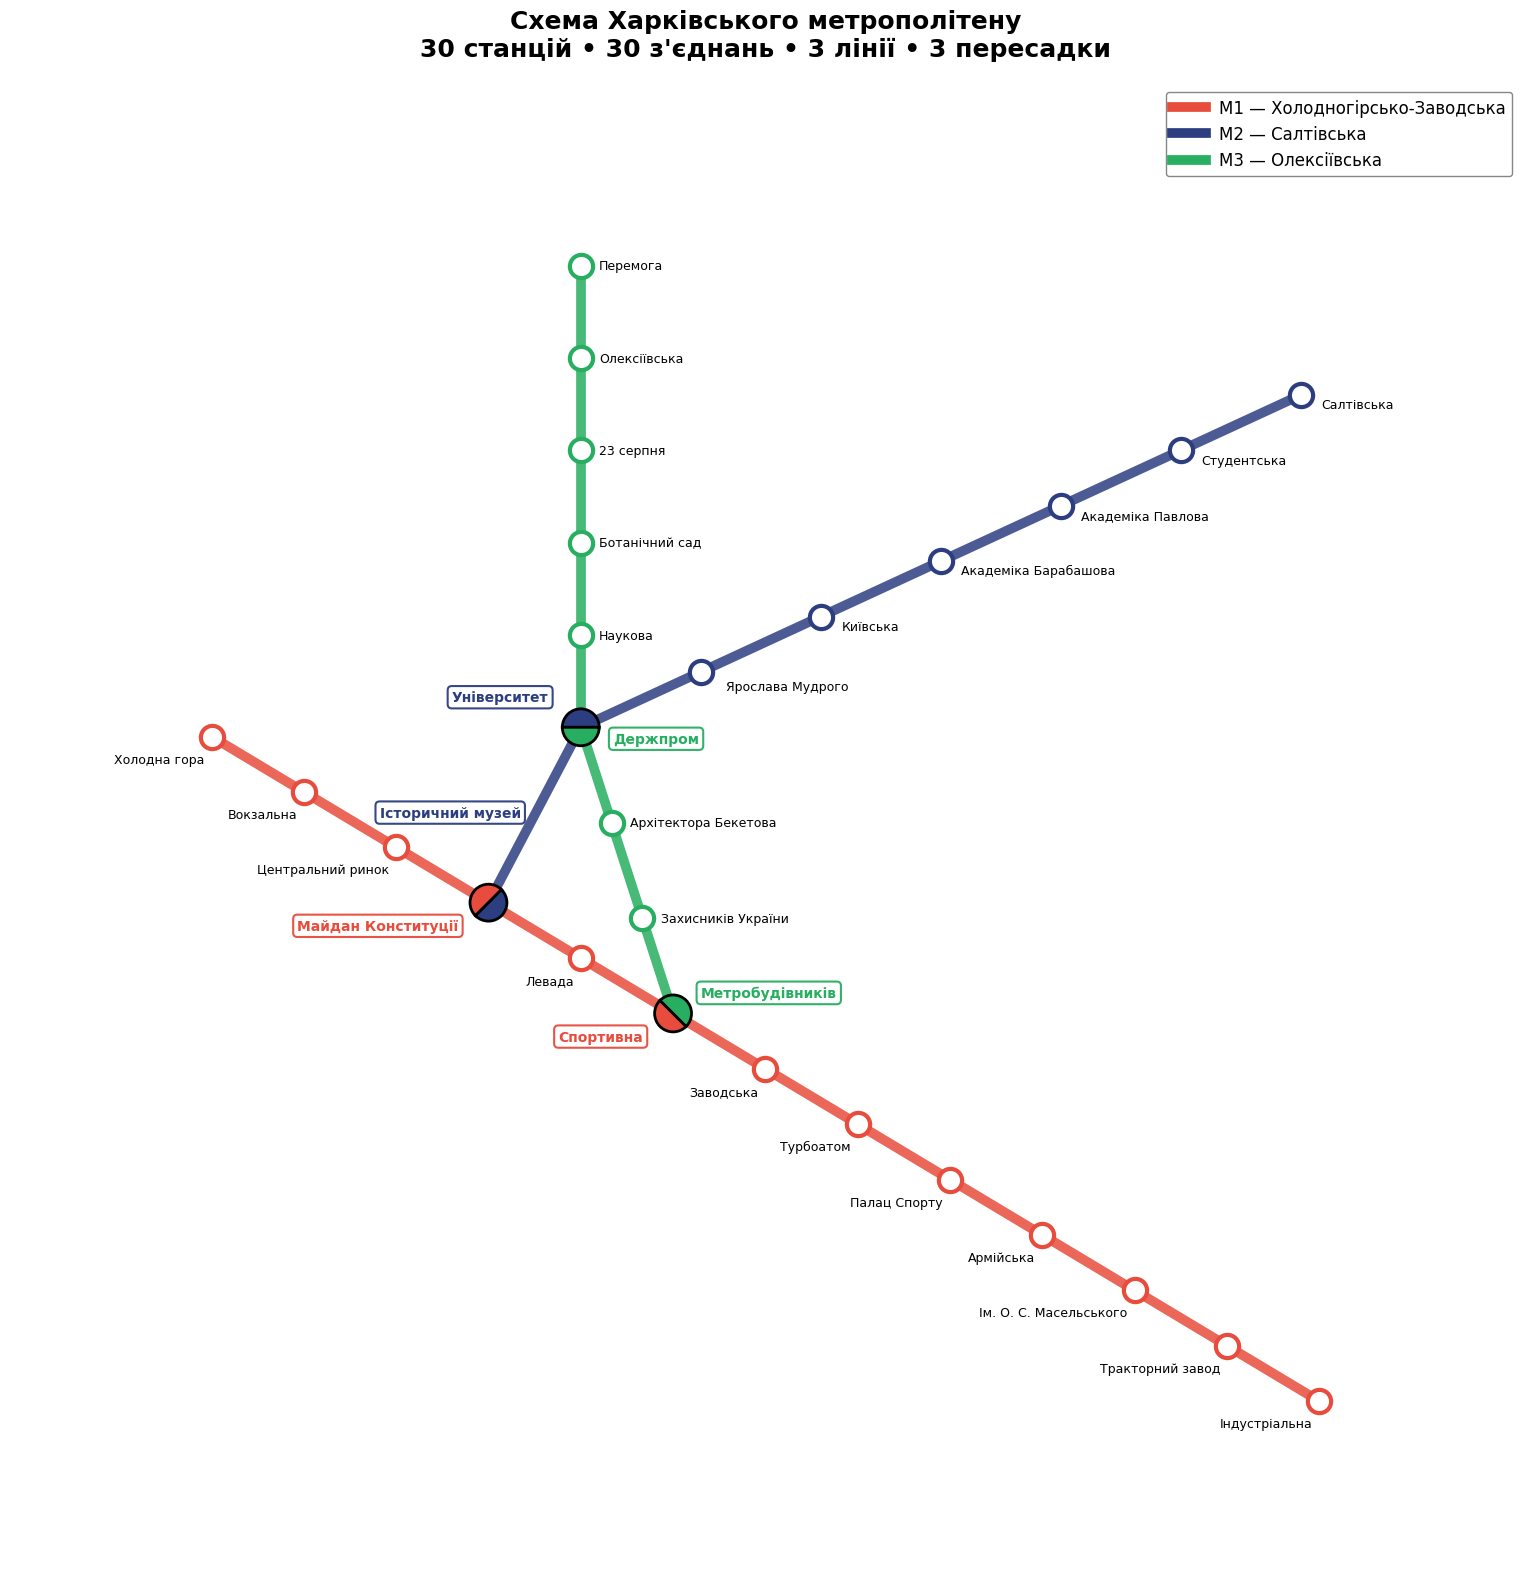

АНАЛІЗ МЕРЕЖІ ХАРКІВСЬКОГО МЕТРО

📊 Базові характеристики:
   Кількість станцій: 30
   Кількість з'єднань: 30
   Щільність: 0.0690
   Зв'язний: Так

📈 Ступені вершин:
   Середній: 2.00
   Максимальний: 3
   Мінімальний: 1

🚪 ТОП-5 ключових станцій (за посередництвом):
   Університет: 0.4433
   Спортивна: 0.4089
   Майдан Конституції: 0.3867
   Держпром: 0.3621
   Заводська: 0.3399

🗺️  Структура:
   Діаметр (перегонів): 17
   Середня відстань: 6.37

🚇 Розподіл станцій:
   M1 (Холодногірсько-Заводська): 13
   M2 (Салтівська): 8
   M3 (Олексіївська): 9


In [10]:
G   = build_graph(LINES, TRANSFERS)
pos = compute_layout(LINES)
draw_metro(G, LINES, TRANSFERS, pos)
print_analysis(G, LINES)

## 📊 Аналіз мережі Харківського метрополітену

Мережа складається з **30 станцій** та **30 з'єднань** (27 перегонів між сусідніми станціями плюс 3 пересадкові з'єднання між лініями). Граф є **зв'язним** — з будь-якої станції можна дістатися до будь-якої іншої, що є базовою вимогою транспортної системи. Щільність графа дуже низька (**0.069**), що характерно для лінійних транспортних мереж: лише близько 7% можливих пар станцій з'єднані безпосередньо. Структура близька до дерева, оскільки три цикли в графі утворюються лише завдяки замкненому трикутнику пересадок у центрі.

### 📈 Ступені вершин

Розподілені від 1 до 3 з точним середнім **2.00**:

- **Ступінь 1** мають шість кінцевих станцій-терміналів — по одному з кожного боку трьох ліній (*Холодна гора, Індустріальна, Перемога, Метробудівників, Салтівська, Історичний музей*).
- **Ступінь 2** — більшість внутрішніх станцій з одним сусідом з кожного боку.
- **Ступінь 3** мають лише пересадкові станції, де до двох сусідів по своїй лінії додається з'єднання з вузлом на іншій лінії.

### 🚪 ТОП-5 ключових станцій за посередництвом

Очікувано очолюють пересадкові вузли:

| № | Станція | Betweenness |
|---|---|---|
| 1 | Університет | **0.443** |
| 2 | Спортивна | **0.409** |
| 3 | Майдан Конституції | **0.387** |
| 4 | Держпром | **0.362** |
| 5 | Заводська | **0.340** |

Через ці чотири пересадкові станції проходить від 36% до 44% усіх найкоротших шляхів у мережі. Особливе місце посідає **Університет** — це єдина пересадка між синьою та зеленою лініями, що робить її критичним вузлом усієї системи: вихід її з ладу призведе до значного подовження маршрутів між північною частиною мережі та центром. П'яте місце посідає **Заводська** — не пересадкова, але стратегічно розташована між пересадкою Спортивна/Метробудівників та південно-східною частиною червоної лінії, тож велика частина шляхів від найвіддаленіших станцій до решти мережі змушена проходити через неї.

### 🗺️ Структурні характеристики

- **Діаметр мережі: 17 перегонів** — найдовший найкоротший шлях між двома станціями, який пролягає між *Індустріальною* та *Салтівською* (кінцеві точки червоної та синьої ліній відповідно).
- **Середня відстань: 6.37 перегону** — типова поїздка триває близько шести зупинок.

### 🚇 Розподіл станцій між лініями

| Лінія | Назва | Станцій |
|---|---|---|
| 🔴 **M1** | Холодногірсько-Заводська | 13 |
| 🟢 **M3** | Олексіївська | 9 |
| 🔵 **M2** | Салтівська | 8 |

Розподіл нерівномірний: червона M1 містить майже вдвічі більше станцій, ніж синя M2. Це відображає історичну розбудову системи — червона лінія є найстарішою та обслуговує найбільшу довжину міста.

### 🎯 Висновки

Мережа має класичну структуру міського метрополітену малого міста: три радіальні лінії, що сходяться в центральному трикутнику пересадок **Університет–Майдан Конституції–Спортивна**. Низька щільність і мала кількість циклів означає **високу структурну вразливість** — вихід з ладу однієї пересадкової станції суттєво погіршує зв'язність мережі.

З точки зору розвитку, ключовим напрямком зміцнення системи могло б стати створення **додаткових пересадок між периферійними ділянками ліній**, що зменшило б навантаження на центральні вузли та підвищило стійкість мережі загалом.

## 🗺️ Планарність графа

**Планарний граф** — це граф, який можна намалювати на площині так, щоб жодні два ребра не перетиналися (за винятком спільних вершин). За теоремою Куратовського граф планарний тоді й тільки тоді, коли він не містить підграфа, що є підрозбиттям K₅ (повного графа на 5 вершинах) або K₃,₃ (повного двочасткового 3+3).

Для зв'язних планарних графів виконується **формула Ейлера**:

$$V - E + F = 2$$

де V — кількість вершин, E — ребер, F — граней (включно з зовнішньою нескінченною).

**Чому транспортні мережі майже завжди планарні:** вони фізично існують на (майже) площинній поверхні Землі. Як тільки два маршрути перетинаються — там зазвичай роблять пересадку, яка стає вершиною графа, а не "перетином ребер". Перевіримо, чи планарний наш граф.

In [11]:
is_planar, _ = nx.check_planarity(G)
V, E = G.number_of_nodes(), G.number_of_edges()
F = 2 - V + E
cycles = nx.cycle_basis(G)

print(f"Граф планарний: {is_planar}")
print(f"V = {V},  E = {E},  F = {F}")
print(f"Формула Ейлера: V − E + F = {V} − {E} + {F} = {V - E + F}  ✓")
print(f"\nЦиклів у базисі: {len(cycles)}")
for i, c in enumerate(cycles, 1):
    print(f"  Цикл {i} ({len(c)} вершин): {' → '.join(c)} → {c[0]}")

Граф планарний: True
V = 30,  E = 30,  F = 2
Формула Ейлера: V − E + F = 30 − 30 + 2 = 2  ✓

Циклів у базисі: 1
  Цикл 1 (9 вершин): Захисників України → Архітектора Бекетова → Держпром → Університет → Історичний музей → Майдан Конституції → Левада → Спортивна → Метробудівників → Захисників України


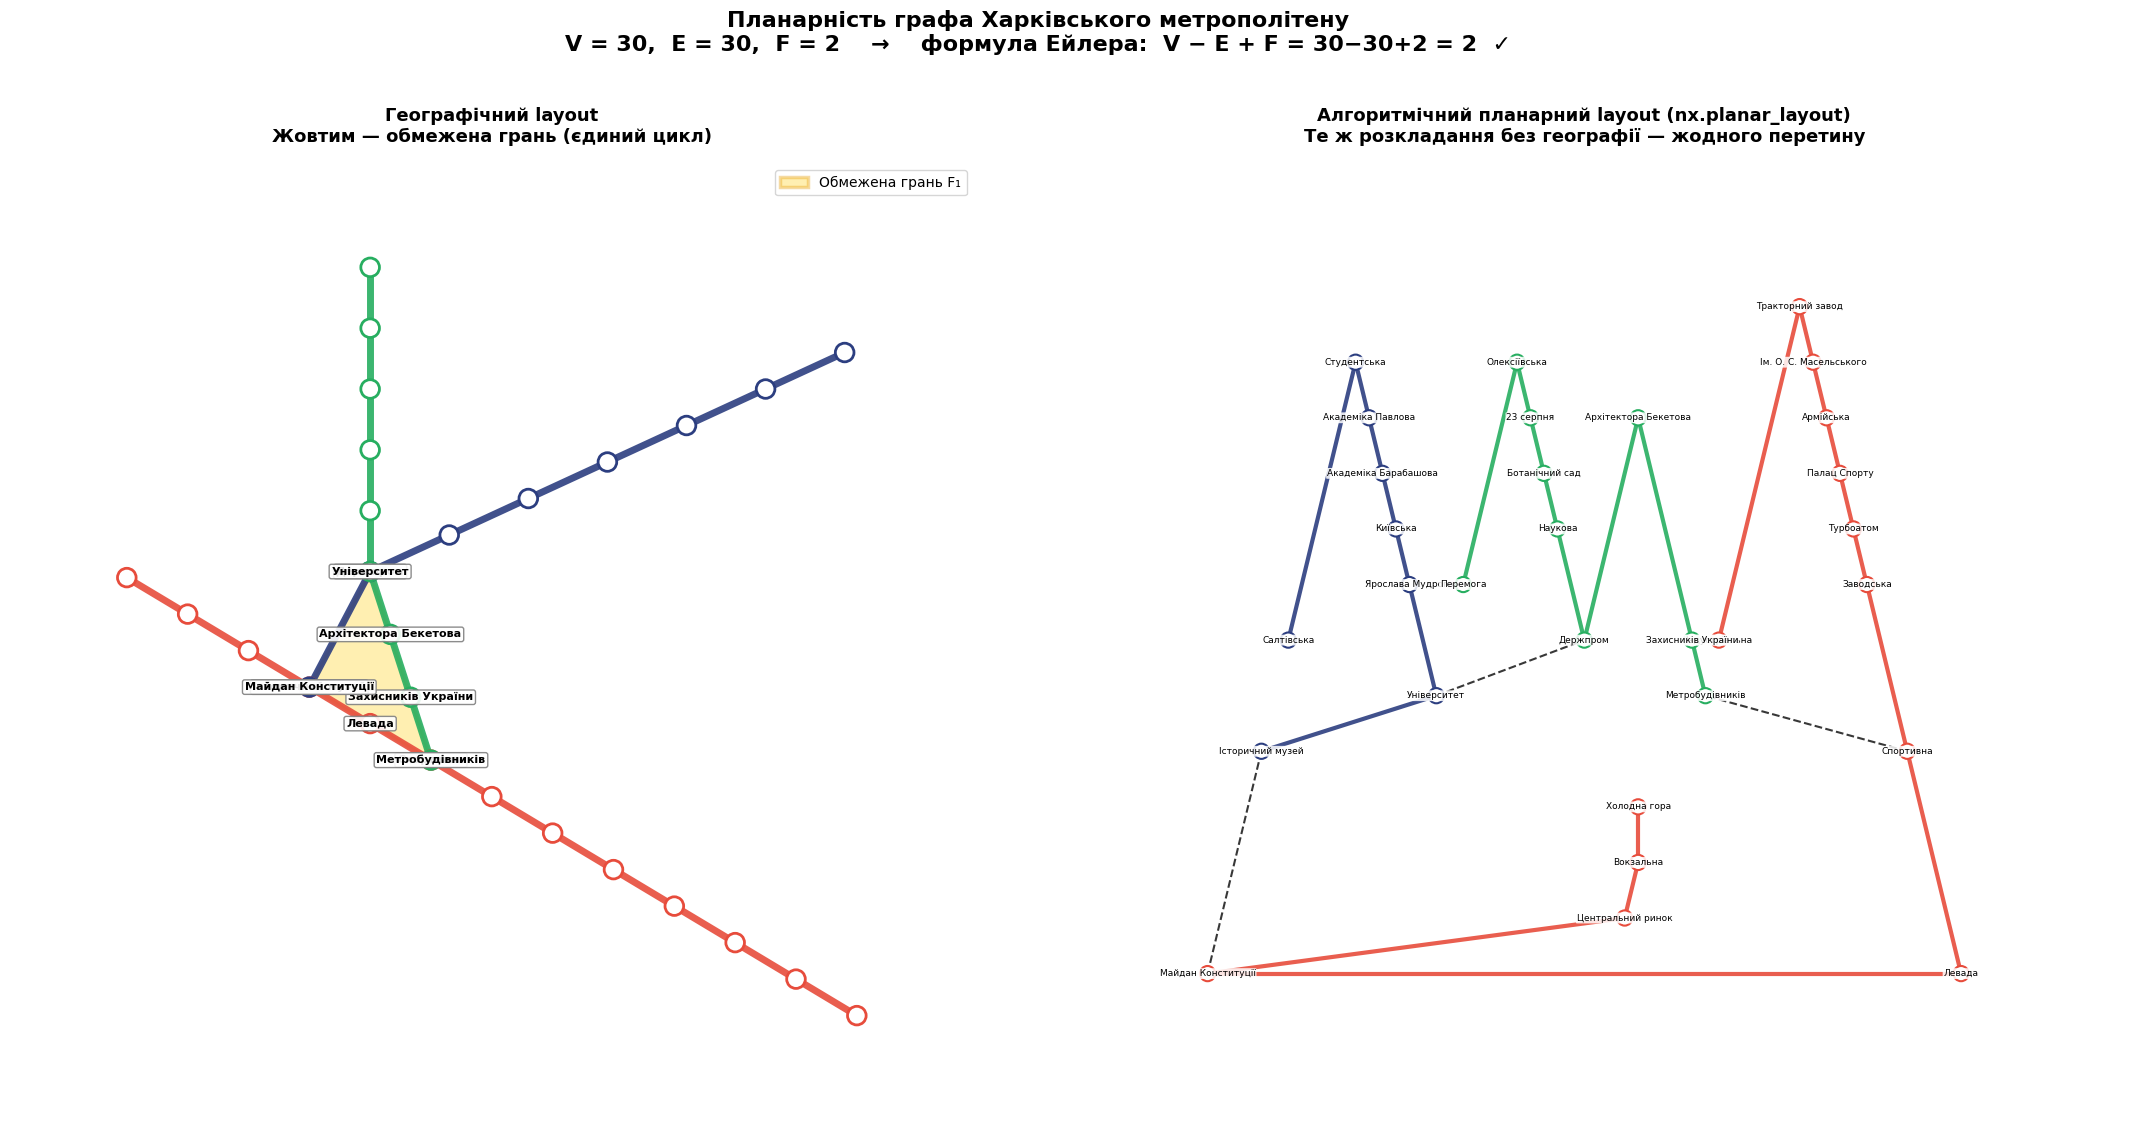

In [12]:
from matplotlib.patches import Polygon


def _unique_consecutive(coords):
    """Видаляє послідовні дублікати — пересадки мають однакові координати."""
    coords = [tuple(c) for c in coords]
    return [c for i, c in enumerate(coords) if i == 0 or coords[i-1] != c]


def draw_planarity(G, lines, transfers):
    color_of, _, _ = build_indexes(lines, transfers)
    cycle = nx.cycle_basis(G)[0]
    transfer_edges = [t.stations for t in transfers]

    fig, axes = plt.subplots(1, 2, figsize=(22, 11), facecolor='white')

    # === ЛІВА: географічний layout з підсвіченою гранню ===
    ax = axes[0]
    pos_geo = compute_layout(lines)
    face = _unique_consecutive([pos_geo[st] for st in cycle])
    ax.add_patch(Polygon(face, facecolor='#FFD93D', edgecolor='#E8A317',
                         alpha=0.4, linewidth=2.5, zorder=1,
                         label='Обмежена грань F₁'))
    for line in lines:
        nx.draw_networkx_edges(G, pos_geo, ax=ax,
                               edgelist=list(zip(line.stations, line.stations[1:])),
                               edge_color=line.color, width=5, alpha=0.9)
    nx.draw_networkx_edges(G, pos_geo, edgelist=transfer_edges, ax=ax,
                           edge_color='#222', width=2, style='dashed', alpha=0.9)
    nx.draw_networkx_nodes(G, pos_geo, ax=ax, node_size=180, node_color='white',
                           edgecolors=[color_of[n] for n in G.nodes()], linewidths=2)
    nx.draw_networkx_labels(G, pos_geo, ax=ax,
                            labels={st: st for st in cycle},
                            font_size=8, font_weight='bold',
                            bbox=dict(boxstyle='round,pad=0.2', facecolor='white',
                                      edgecolor='gray', alpha=0.9))
    ax.set_title("Географічний layout\nЖовтим — обмежена грань (єдиний цикл)",
                 fontsize=13, fontweight='bold', pad=15)
    ax.legend(loc='upper right', fontsize=10)
    ax.set_axis_off()
    ax.set_aspect('equal')
    ax.margins(0.1)

    # === ПРАВА: алгоритмічний планарний layout ===
    ax = axes[1]
    pos_planar = nx.planar_layout(G, scale=2)
    for line in lines:
        nx.draw_networkx_edges(G, pos_planar, ax=ax,
                               edgelist=list(zip(line.stations, line.stations[1:])),
                               edge_color=line.color, width=3, alpha=0.9)
    nx.draw_networkx_edges(G, pos_planar, edgelist=transfer_edges, ax=ax,
                           edge_color='#222', width=1.5, style='dashed', alpha=0.9)
    nx.draw_networkx_nodes(G, pos_planar, ax=ax, node_size=120, node_color='white',
                           edgecolors=[color_of[n] for n in G.nodes()], linewidths=1.5)
    nx.draw_networkx_labels(G, pos_planar, ax=ax, font_size=6.5,
                            bbox=dict(boxstyle='round,pad=0.1', facecolor='white',
                                      edgecolor='none', alpha=0.85))
    ax.set_title("Алгоритмічний планарний layout (nx.planar_layout)\n"
                 "Те ж розкладання без географії — жодного перетину",
                 fontsize=13, fontweight='bold', pad=15)
    ax.set_axis_off()
    ax.margins(0.15)

    fig.suptitle(
        f"Планарність графа Харківського метрополітену\n"
        f"V = {V},  E = {E},  F = {F}    →    "
        f"формула Ейлера:  V − E + F = {V}−{E}+{F} = 2  ✓",
        fontsize=16, fontweight='bold', y=1.02,
    )
    plt.tight_layout()
    plt.show()


draw_planarity(G, LINES, TRANSFERS)

### Висновок

Граф Харківського метрополітену є **планарним** (підтверджено алгоритмом `nx.check_planarity` та формулою Ейлера: V − E + F = 30 − 30 + 2 = 2). Це означає, що мережу можна намалювати на площині без жодного перетину ребер — що ми і робимо у звичній схемі метро.

**Циклічний ранг мережі μ = E − V + 1 = 1** — у графі існує рівно один незалежний цикл (девʼятивершинна петля навколо центрального трикутника пересадок). Це найважливіша структурна характеристика: з 30 ребер лише 9 належать цьому циклу, а решта 21 є **мостами** — їхнє видалення розриває мережу на дві незв'язні компоненти. Лише в межах цього єдиного циклу існує альтернативний маршрут між станціями; всі інші частини мережі мають по одному єдиному шляху, що робить їх критично вразливими до відключень.

За нерівністю Ейлера для простих планарних графів виконується **E ≤ 3V − 6**, тобто для нашого випадку 30 ≤ 84. Мережа використовує лише близько 36% теоретично дозволеного запасу планарності. Це означає, що до системи можна додати велику кількість нових ліній або пересадок, і граф залишиться планарним. З практичної точки зору планувальники мають значний простір для розширення мережі без ризику топологічних проблем.

Планарність харківського метро не є випадковою властивістю, а **відображає універсальну закономірність усіх реальних транспортних мереж**: вони фізично існують на (майже) двовимірній поверхні Землі, тому їхні графові моделі майже завжди планарні. Перетин маршрутів у реальному світі практично завжди супроводжується пересадковою станцією, яка в графі стає окремою вершиною, а не "перехрестом ребер". Таким чином, планарність є природним інваріантом міських транспортних систем, який варто враховувати при проектуванні нових ліній — будь-яке розширення мережі повинно зберігати цю властивість.

# Завдання 2. Пошук шляхів через DFS і BFS

Для побудованого графа потрібно знайти шляхи між станціями двома алгоритмами обходу — **BFS** (пошук у ширину) та **DFS** (пошук у глибину) — і порівняти результати.

Граф зв'язний (це підтверджено в аналізі завдання 1), тому між будь-якими двома станціями існує хоча б один шлях. Обидва алгоритми мають складність O(V + E) і для графа з 30 вершин та 30 ребер виконуються миттєво.

**Принципова різниця між алгоритмами:**

- **BFS** обходить граф рівнями: спочатку усі сусіди стартової вершини, потім усі сусіди сусідів, і так далі. На неоднозначних графах **гарантовано знаходить найкоротший шлях** (за кількістю ребер).
- **DFS** іде якнайглибше в одному напрямку, поки не впреться у відвідану вершину або тупик, а потім повертається назад (backtracking). **Не гарантує найкоротшого шляху** — може повернутися з довгим маршрутом, якщо обрав "довший" напрямок на роздоріжжі.

### **Логіка добору тестових пар станцій**

Чотири пари обиралися свідомо, щоб показати **різні топологічні ситуації** і продемонструвати, коли DFS відрізняється від BFS, а коли ні. З аналізу планарності в завданні 1 ми знаємо, що цикловий ранг графа μ = 1 — у мережі є рівно один цикл, центральна петля з 9 вершин. Між парами станцій, де хоча б один кінець не лежить на цьому циклі, маршрут зазвичай єдиний — і обидва алгоритми дадуть однаковий результат. Різниця виникає лише там, де є вибір "з якого боку" обходити центральну петлю. Тому тестові пари добиралися так, щоб покрити обидві ситуації і показати прогресію — від ідентичних результатів до драматичної відмінності.

**Холодна гора → Салтівська** (BFS = DFS = 11) — це маршрут між кінцевими станціями двох різних ліній, фактично через усю мережу. Здавалося б, тут має бути різниця, але результати збіглися. Цей приклад є **контрприкладом**: він показує, що сама лише довжина маршруту чи проходження через цикл не гарантують різниці алгоритмів. Обидві станції лежать на "хвостах" поза циклом, тому вхід (через Майдан Конституції) і вихід (через Університет) географічно зафіксовані — обидва алгоритми змушені знайти один і той самий маршрут.

**Університет → Спортивна** (BFS = 4, DFS = 5) — найбільш **дидактичний** приклад. Обидві станції є вершинами центрального циклу, тож шлях буквально лежить усередині петлі, а два можливі маршрути — це обхід циклу з протилежних боків. BFS обирає коротший бік (через Майдан Конституції/Історичний музей), DFS — довший (через Держпром і зелену лінію). Різниця становить лише одне ребро, але візуально на схемі видно дуже чітко — це канонічний приклад "однаково можливих, але різних за довжиною шляхів".

**Перемога → Індустріальна** (BFS = 16, DFS = 17) — найдовший маршрут через все місто, фактично близький до діаметра графа (17 перегонів). Цікавий висновок: різниця становить лише 1 перегон, хоча сам маршрут дуже довгий. Це показує, що відмінність між BFS і DFS **не залежить від загальної довжини шляху** — вона виникає тільки у локальній зоні навколо циклу, а на ділянках поза ним обидва алгоритми йдуть одним і тим самим маршрутом.

**Вокзальна → Тракторний завод** (BFS = 10, DFS = 15) — найдраматичніший приклад з різницею у 50%. Пара обрана так, що обидві станції лежать на одній лінії (червоній). Інтуїтивно здавалось би, що тут різниці бути не може взагалі — їдь собі прямо. Але виходить навпаки: DFS бачить пересадку на Майдан Конституції, обирає її і робить великий гак через синю та зелену лінії, перш ніж повернутися на червону. Цей приклад найкраще ілюструє головну ваду DFS — алгоритм не "знає", що залишається на правильній лінії, він просто йде туди, куди вказує перший доступний сусід.

**Що дає ця четвірка разом.** Перші три приклади (різниця 0–1 перегон) показують, що завдяки малому цикловому рангу графа відмінність BFS і DFS на метро Харкова зазвичай невелика — більшість шляхів унікальні. Четвертий приклад руйнує цю наївну картину: навіть на одній лінії DFS може поводитися несподівано погано, якщо натрапляє на пересадку. Разом ці пари дають повну картину поведінки алгоритмів — коли вони збігаються, чому, і коли різниця стає критичною.

In [13]:
from collections import deque


def bfs_path(G, start, end):
    """Найкоротший шлях через BFS (пошук у ширину)."""
    if start == end:
        return [start]
    visited = {start}
    queue = deque([(start, [start])])
    while queue:
        node, path = queue.popleft()
        for neighbor in G.neighbors(node):
            if neighbor in visited:
                continue
            if neighbor == end:
                return path + [neighbor]
            visited.add(neighbor)
            queue.append((neighbor, path + [neighbor]))
    return None


def dfs_path(G, start, end):
    """Шлях через DFS (пошук у глибину) — ітеративна реалізація через стек."""
    if start == end:
        return [start]
    visited = {start}
    stack = [(start, [start])]
    while stack:
        node, path = stack.pop()
        for neighbor in G.neighbors(node):
            if neighbor in visited:
                continue
            if neighbor == end:
                return path + [neighbor]
            visited.add(neighbor)
            stack.append((neighbor, path + [neighbor]))
    return None

In [14]:
test_pairs = [
    ("Холодна гора",   "Салтівська"),         # обидва кінці — через увесь центр
    ("Університет",    "Спортивна"),          # обхід циклу з різних боків
    ("Перемога",       "Індустріальна"),      # кінець-в-кінець через все місто
    ("Вокзальна",      "Тракторний завод"),   # обидві на М1 — є єдиний прямий шлях
]

# Збираємо результати у список
results = []
for s, e in test_pairs:
    bfs = bfs_path(G, s, e)
    dfs = dfs_path(G, s, e)
    same = "так" if bfs == dfs else "ні"
    results.append((f"{s} → {e}", len(bfs) - 1, len(dfs) - 1, same))

# Динамічно вираховуємо ширину колонки "Маршрут"
w = max(len(r[0]) for r in results)
header = f"{'Маршрут':<{w}}  {'BFS':>4}  {'DFS':>4}  Збіг"
print(header)
print("=" * len(header))
for route, bfs_len, dfs_len, same in results:
    print(f"{route:<{w}}  {bfs_len:>4}  {dfs_len:>4}  {same}")

# Деталі обох шляхів для одного цікавого прикладу
s, e = "Університет", "Спортивна"
print(f"\nДеталі: {s} → {e}\n")
print(f"BFS ({len(bfs_path(G, s, e)) - 1} перегонів):")
print("  " + " → ".join(bfs_path(G, s, e)))
print(f"\nDFS ({len(dfs_path(G, s, e)) - 1} перегонів):")
print("  " + " → ".join(dfs_path(G, s, e)))

Маршрут                        BFS   DFS  Збіг
Холодна гора → Салтівська       11    11  так
Університет → Спортивна          4     5  ні
Перемога → Індустріальна        16    17  ні
Вокзальна → Тракторний завод    10    15  ні

Деталі: Університет → Спортивна

BFS (4 перегонів):
  Університет → Історичний музей → Майдан Конституції → Левада → Спортивна

DFS (5 перегонів):
  Університет → Держпром → Архітектора Бекетова → Захисників України → Метробудівників → Спортивна


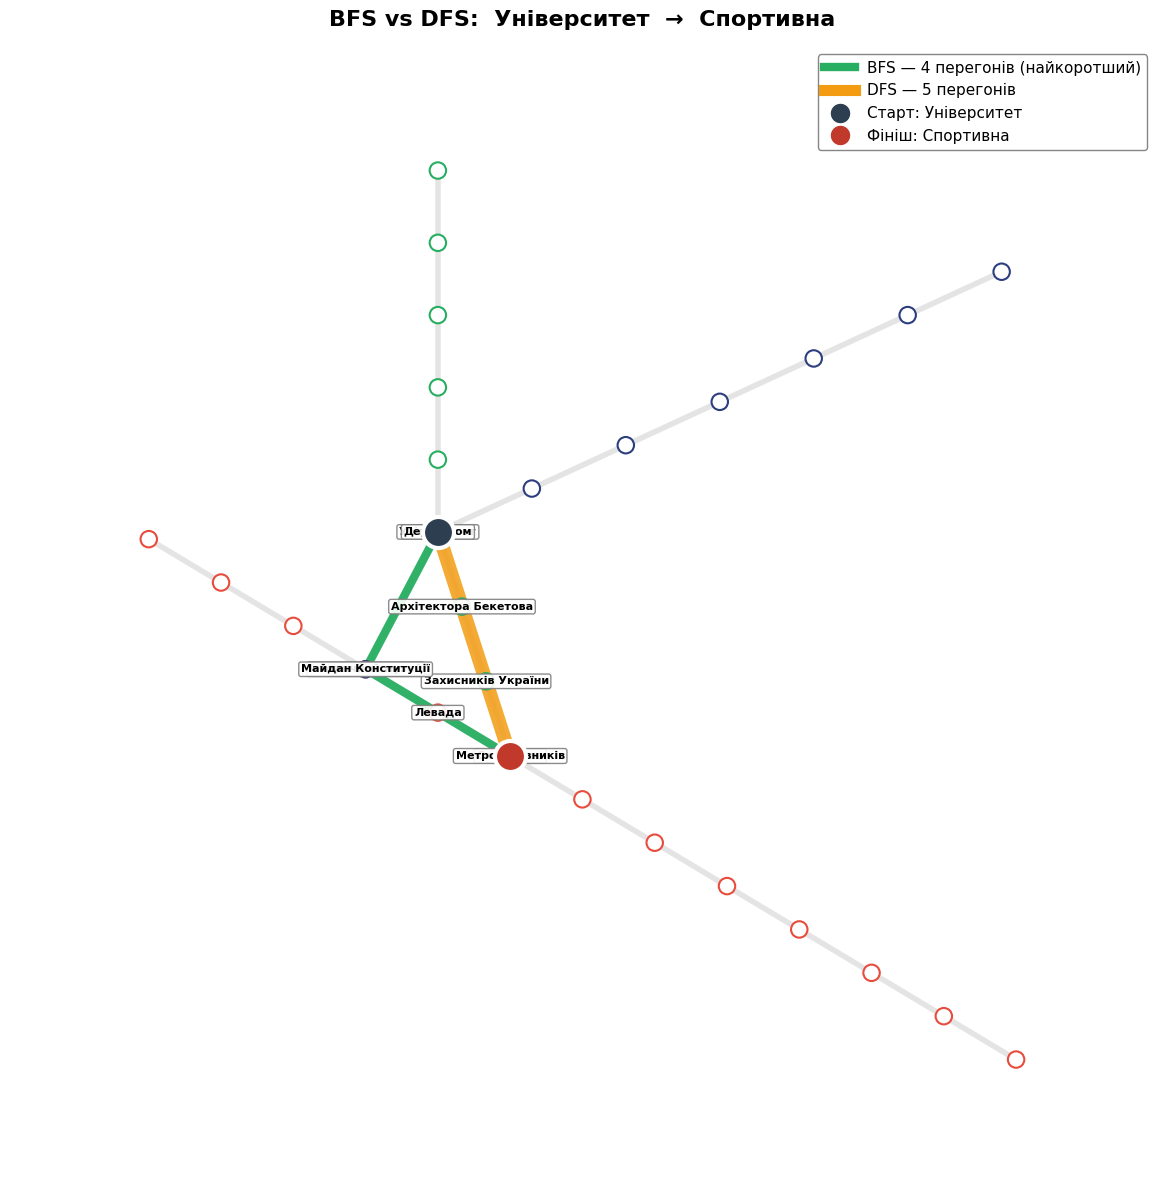

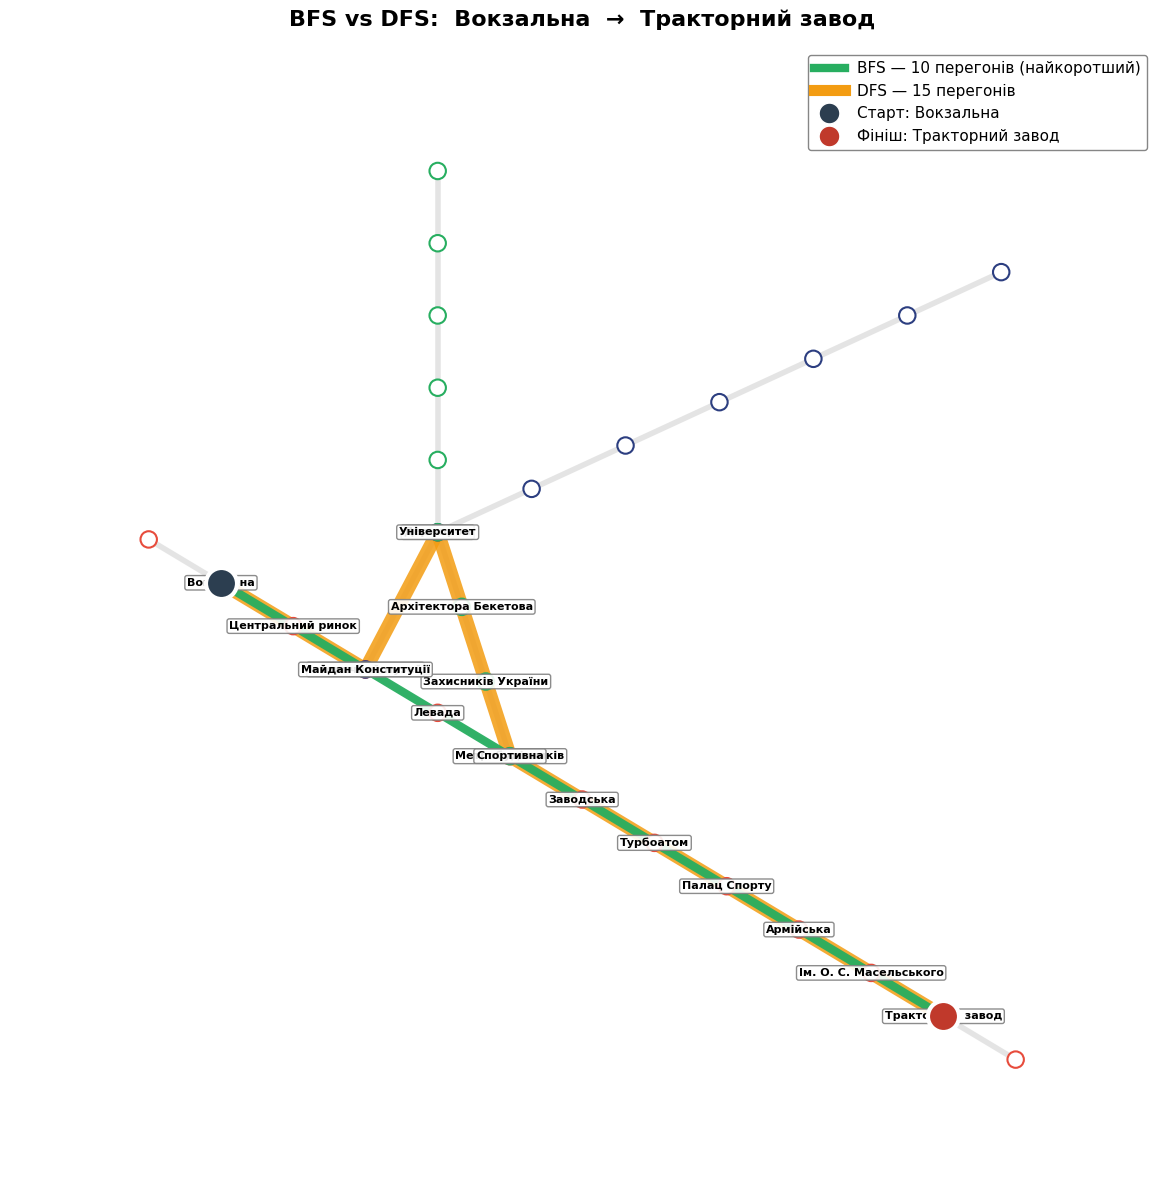

In [15]:
from matplotlib.lines import Line2D


def visualize_paths(G, lines, transfers, pos, start, end):
    color_of, _, _ = build_indexes(lines, transfers)
    bfs = bfs_path(G, start, end)
    dfs = dfs_path(G, start, end)
    bfs_edges = list(zip(bfs, bfs[1:]))
    dfs_edges = list(zip(dfs, dfs[1:]))

    fig, ax = plt.subplots(figsize=(16, 12), facecolor='white')

    # Сіра підкладка — вся мережа
    for line in lines:
        edges = list(zip(line.stations, line.stations[1:]))
        nx.draw_networkx_edges(G, pos, edgelist=edges, ax=ax,
                               edge_color='lightgray', width=4, alpha=0.6)
    transfer_edges = [t.stations for t in transfers]
    nx.draw_networkx_edges(G, pos, edgelist=transfer_edges, ax=ax,
                           edge_color='lightgray', width=2, style='dashed', alpha=0.6)
    nx.draw_networkx_nodes(G, pos, ax=ax, node_size=140, node_color='white',
                           edgecolors=[color_of[n] for n in G.nodes()], linewidths=1.5)

    # DFS товстіший знизу, BFS — поверх
    nx.draw_networkx_edges(G, pos, edgelist=dfs_edges, ax=ax,
                           edge_color='#F39C12', width=10, alpha=0.85)
    nx.draw_networkx_edges(G, pos, edgelist=bfs_edges, ax=ax,
                           edge_color='#27AE60', width=6, alpha=0.95)

    # Старт/фініш
    for st, color in [(start, '#2C3E50'), (end, '#C0392B')]:
        x, y = pos[st]
        ax.scatter(x, y, s=500, c=color, edgecolors='white',
                   linewidths=3, zorder=10)

    # Підписи лише для задіяних станцій
    used = set(bfs) | set(dfs)
    nx.draw_networkx_labels(G, pos, labels={st: st for st in used}, ax=ax,
                            font_size=8, font_weight='bold',
                            bbox=dict(boxstyle='round,pad=0.2', facecolor='white',
                                      edgecolor='gray', alpha=0.9))

    legend_handles = [
        Line2D([0], [0], color='#27AE60', linewidth=6,
               label=f'BFS — {len(bfs)-1} перегонів (найкоротший)'),
        Line2D([0], [0], color='#F39C12', linewidth=8,
               label=f'DFS — {len(dfs)-1} перегонів'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor='#2C3E50',
               markersize=15, label=f'Старт: {start}'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor='#C0392B',
               markersize=15, label=f'Фініш: {end}'),
    ]
    ax.legend(handles=legend_handles, loc='upper right', fontsize=11,
              framealpha=0.95, edgecolor='gray')
    ax.set_title(f"BFS vs DFS:  {start}  →  {end}",
                 fontsize=16, fontweight='bold', pad=15)
    ax.set_axis_off()
    ax.set_aspect('equal')
    ax.margins(0.1)
    plt.tight_layout()
    plt.show()


visualize_paths(G, LINES, TRANSFERS, pos, "Університет", "Спортивна")
visualize_paths(G, LINES, TRANSFERS, pos, "Вокзальна", "Тракторний завод")

## Порівняння результатів BFS і DFS

### Чому шляхи саме такі

**BFS гарантує найкоротший шлях**, бо обходить граф рівнями: спочатку всі вершини на відстані 1 від старту, потім на відстані 2, і так далі. Перший раз, коли алгоритм досягає кінцевої станції, він робить це найкоротшим маршрутом — це фундаментальна властивість пошуку в ширину для неоднозначних графів.

**DFS не оптимізує довжину**, бо просто йде якнайглибше в одному напрямку. Він знаходить *перший-ліпший* шлях, не порівнюючи його з альтернативами. Якщо на роздоріжжі він обрав "довшу" гілку, він пройде нею до кінцевої станції — і поверне її, навіть якщо коротший варіант існує.

### Коли алгоритми дають однакові результати

У нашому графі **21 з 30 ребер є мостами** (це показав аналіз планарності в завданні 1 — циклічний ранг μ = 1). Це означає, що між більшістю пар станцій існує лише **один-єдиний шлях** — і обидва алгоритми змушені знайти саме його.

Різниця проявляється лише тоді, коли і старт, і фініш розташовані так, що шлях має проходити через **центральний цикл з 9 станцій** (Університет/Держпром → Архітектора Бекетова → Захисників України → Метробудівників/Спортивна → Левада → Майдан Конституції/Історичний музей → і назад). Тільки в межах цього циклу існують два альтернативні маршрути, і BFS обирає коротший, а DFS — той, у напрямку якого першими додавалися ребра.

### Аналіз конкретних маршрутів

**«Університет → Спортивна»** (4 проти 5 перегонів). Це ідеальний приклад роботи всередині циклу:
- **BFS** іде Університет → Історичний музей → Майдан Конституції → Левада → Спортивна — обхід циклу по «короткій» стороні через дві пересадки.
- **DFS** іде Університет → Держпром → Архітектора Бекетова → Захисників України → Метробудівників → Спортивна — обхід тієї ж петлі з протилежного боку, через зелену лінію.

Обидва шляхи лежать у центральному циклі, тому обидва геометрично «правильні», але BFS обирає коротший.

**«Вокзальна → Тракторний завод»** (10 проти 15 перегонів). Тут різниця найдраматичніша:
- **BFS** прямо по червоній лінії — Вокзальна → Центральний ринок → Майдан Конституції → Левада → Спортивна → Заводська → Турбоатом → Палац Спорту → Армійська → Ім. О. С. Масельського → Тракторний завод.
- **DFS** робить «гак» — від Майдан Конституції піднімається через пересадку на синю лінію до Університет, потім по зеленій до Метробудівників, повертається на червону до Спортивної і далі. Це 5 «зайвих» перегонів через те, що алгоритм у Майдан Конституції першим обрав напрям убік, замість продовжити по червоній.

**«Холодна гора → Салтівська»** (11 проти 11, шляхи **збігаються**). Тут обидва кінці лежать поза центральним циклом — на «хвостах» червоної та синьої ліній. Через цикл потрібно пройти, але вхід і вихід жорстко зафіксовані. Тому є лише один найкоротший маршрут, який знаходять обидва алгоритми.

### Загальний висновок

DFS і BFS на цьому графі демонструють класичну поведінку:
- BFS — оптимальний для пошуку **найкоротшого** маршруту (за кількістю перегонів);
- DFS — швидкий для перевірки **самого факту досяжності**, але може дати неоптимальний шлях.

Для практичної задачі планування поїздки метро BFS є очевидним вибором — він гарантує мінімум перегонів. DFS у транспортних застосуваннях зазвичай використовують для інших цілей: пошуку компонентів зв'язності, виявлення циклів, топологічного сортування — там, де довжина шляху не критична.

# Завдання 3. Алгоритм Дейкстри на зваженому графі

У попередніх завданнях усі ребра вважалися рівнозначними — рахувалася лише кількість перегонів. Тепер додамо до графа **ваги**, що відповідають реальному часу руху поїздів між сусідніми станціями (у хвилинах), а пересадкам — часу переходу між платформами. Для зваженого графа BFS уже не дає найкоротшого шляху за часом (бо враховує лише кількість ребер), тому використовуємо **алгоритм Дейкстри**.

**Принцип роботи Дейкстри.** Алгоритм починає зі стартової вершини з відстанню 0 і поступово "відкриває" найближчі вершини, кожного разу обираючи ще не відвідану вершину з найменшою поточною відстанню. Для оптимальної реалізації використовується **бінарна купа** (priority queue) — це дає складність O((V + E) · log V). Для нашого графа з 30 вершинами і 30 ребрами це миттєво.

**Дані про ваги.** Час руху між сусідніми станціями взято з розкладу метро (2–4 хв на перегон). Часи пересадок: Університет ↔ Держпром — 6 хв (різні лінії, треба перейти через довгий тунель), Історичний музей ↔ Майдан Конституції — 5 хв, Спортивна ↔ Метробудівників — 3 хв.

In [16]:
import heapq

# Час руху між сусідніми станціями (хв)
EDGE_WEIGHTS = {
    # M1 — червона
    ("Холодна гора", "Вокзальна"): 3,
    ("Вокзальна", "Центральний ринок"): 2,
    ("Центральний ринок", "Майдан Конституції"): 2,
    ("Майдан Конституції", "Левада"): 2,
    ("Левада", "Спортивна"): 2,
    ("Спортивна", "Заводська"): 2,
    ("Заводська", "Турбоатом"): 2,
    ("Турбоатом", "Палац Спорту"): 3,
    ("Палац Спорту", "Армійська"): 2,
    ("Армійська", "Ім. О. С. Масельського"): 2,
    ("Ім. О. С. Масельського", "Тракторний завод"): 2,
    ("Тракторний завод", "Індустріальна"): 3,
    # M2 — синя
    ("Салтівська", "Студентська"): 2,
    ("Студентська", "Академіка Павлова"): 2,
    ("Академіка Павлова", "Академіка Барабашова"): 2,
    ("Академіка Барабашова", "Київська"): 4,
    ("Київська", "Ярослава Мудрого"): 2,
    ("Ярослава Мудрого", "Університет"): 2,
    ("Університет", "Історичний музей"): 4,
    # M3 — зелена
    ("Перемога", "Олексіївська"): 2,
    ("Олексіївська", "23 серпня"): 3,
    ("23 серпня", "Ботанічний сад"): 2,
    ("Ботанічний сад", "Наукова"): 2,
    ("Наукова", "Держпром"): 2,
    ("Держпром", "Архітектора Бекетова"): 2,
    ("Архітектора Бекетова", "Захисників України"): 4,
    ("Захисників України", "Метробудівників"): 2,
    # Пересадки
    ("Майдан Конституції", "Історичний музей"): 5,
    ("Університет", "Держпром"): 6,
    ("Спортивна", "Метробудівників"): 3,
}


def build_weighted_graph(lines, transfers, weights):
    """Будує граф з вагами на ребрах. weights — dict {(u, v): час, хв}."""
    G = nx.Graph()
    for line in lines:
        G.add_nodes_from(line.stations)
        for u, v in zip(line.stations, line.stations[1:]):
            w = weights.get((u, v)) or weights[(v, u)]
            G.add_edge(u, v, weight=w)
    for t in transfers:
        u, v = t.stations
        w = weights.get((u, v)) or weights[(v, u)]
        G.add_edge(u, v, weight=w)
    return G


GW = build_weighted_graph(LINES, TRANSFERS, EDGE_WEIGHTS)
print(f"Зважений граф: {GW.number_of_nodes()} вершин, {GW.number_of_edges()} ребер")

Зважений граф: 30 вершин, 30 ребер


In [17]:
def dijkstra(G, start):
    """Найкоротші відстані від start до всіх інших вершин.
    Повертає (distances, predecessors) — для відновлення шляхів.
    """
    distances = {node: float('inf') for node in G.nodes()}
    distances[start] = 0
    predecessors = {node: None for node in G.nodes()}
    heap = [(0, start)]
    visited = set()

    while heap:
        d, u = heapq.heappop(heap)
        if u in visited:
            continue
        visited.add(u)
        for v in G.neighbors(u):
            if v in visited:
                continue
            new_d = d + G[u][v]['weight']
            if new_d < distances[v]:
                distances[v] = new_d
                predecessors[v] = u
                heapq.heappush(heap, (new_d, v))

    return distances, predecessors


def reconstruct_path(predecessors, end):
    """Відновлює шлях від старту до end, рухаючись по мапі предків."""
    path = []
    while end is not None:
        path.append(end)
        end = predecessors[end]
    return list(reversed(path))


def shortest_path(G, start, end):
    """Найкоротший шлях і його загальний час між start і end."""
    distances, predecessors = dijkstra(G, start)
    if distances[end] == float('inf'):
        return None, None
    return reconstruct_path(predecessors, end), distances[end]


def all_pairs_shortest_times(G):
    """Найкоротші часи між усіма парами вершин — матриця V×V."""
    return {start: dijkstra(G, start)[0] for start in G.nodes()}

In [18]:
test_pairs = [
    ("Холодна гора", "Салтівська"),
    ("Університет", "Спортивна"),
    ("Перемога", "Індустріальна"),
    ("Вокзальна", "Тракторний завод"),
    ("Холодна гора", "Індустріальна"),
]

results = []
for s, e in test_pairs:
    path, t = shortest_path(GW, s, e)
    results.append((f"{s} → {e}", t, len(path) - 1))

w = max(len(r[0]) for r in results)
header = f"{'Маршрут':<{w}}  {'Час':>5}  {'Перегонів':>10}"
print(header)
print("=" * len(header))
for route, t, n in results:
    print(f"{route:<{w}}  {t:>3} хв  {n:>10}")

# Детальний маршрут
s, e = "Холодна гора", "Салтівська"
path, total = shortest_path(GW, s, e)
print(f"\nДетально: {s} → {e}  (загальний час {total} хв)\n")
for u, v in zip(path, path[1:]):
    print(f"  {u}  ──{GW[u][v]['weight']} хв──→  {v}")

# Зважений діаметр — найдовший найкоротший шлях
all_times = all_pairs_shortest_times(GW)
diam_pair = max(
    ((s, e) for s in all_times for e in all_times[s] if s != e),
    key=lambda p: all_times[p[0]][p[1]],
)
print(f"\nЗважений діаметр: {diam_pair[0]} → {diam_pair[1]} "
      f"= {all_times[diam_pair[0]][diam_pair[1]]} хв")

Маршрут                         Час   Перегонів
Холодна гора → Салтівська      30 хв          11
Університет → Спортивна        13 хв           4
Перемога → Індустріальна       38 хв          16
Вокзальна → Тракторний завод   21 хв          10
Холодна гора → Індустріальна   27 хв          12

Детально: Холодна гора → Салтівська  (загальний час 30 хв)

  Холодна гора  ──3 хв──→  Вокзальна
  Вокзальна  ──2 хв──→  Центральний ринок
  Центральний ринок  ──2 хв──→  Майдан Конституції
  Майдан Конституції  ──5 хв──→  Історичний музей
  Історичний музей  ──4 хв──→  Університет
  Університет  ──2 хв──→  Ярослава Мудрого
  Ярослава Мудрого  ──2 хв──→  Київська
  Київська  ──4 хв──→  Академіка Барабашова
  Академіка Барабашова  ──2 хв──→  Академіка Павлова
  Академіка Павлова  ──2 хв──→  Студентська
  Студентська  ──2 хв──→  Салтівська

Зважений діаметр: Індустріальна → Салтівська = 43 хв


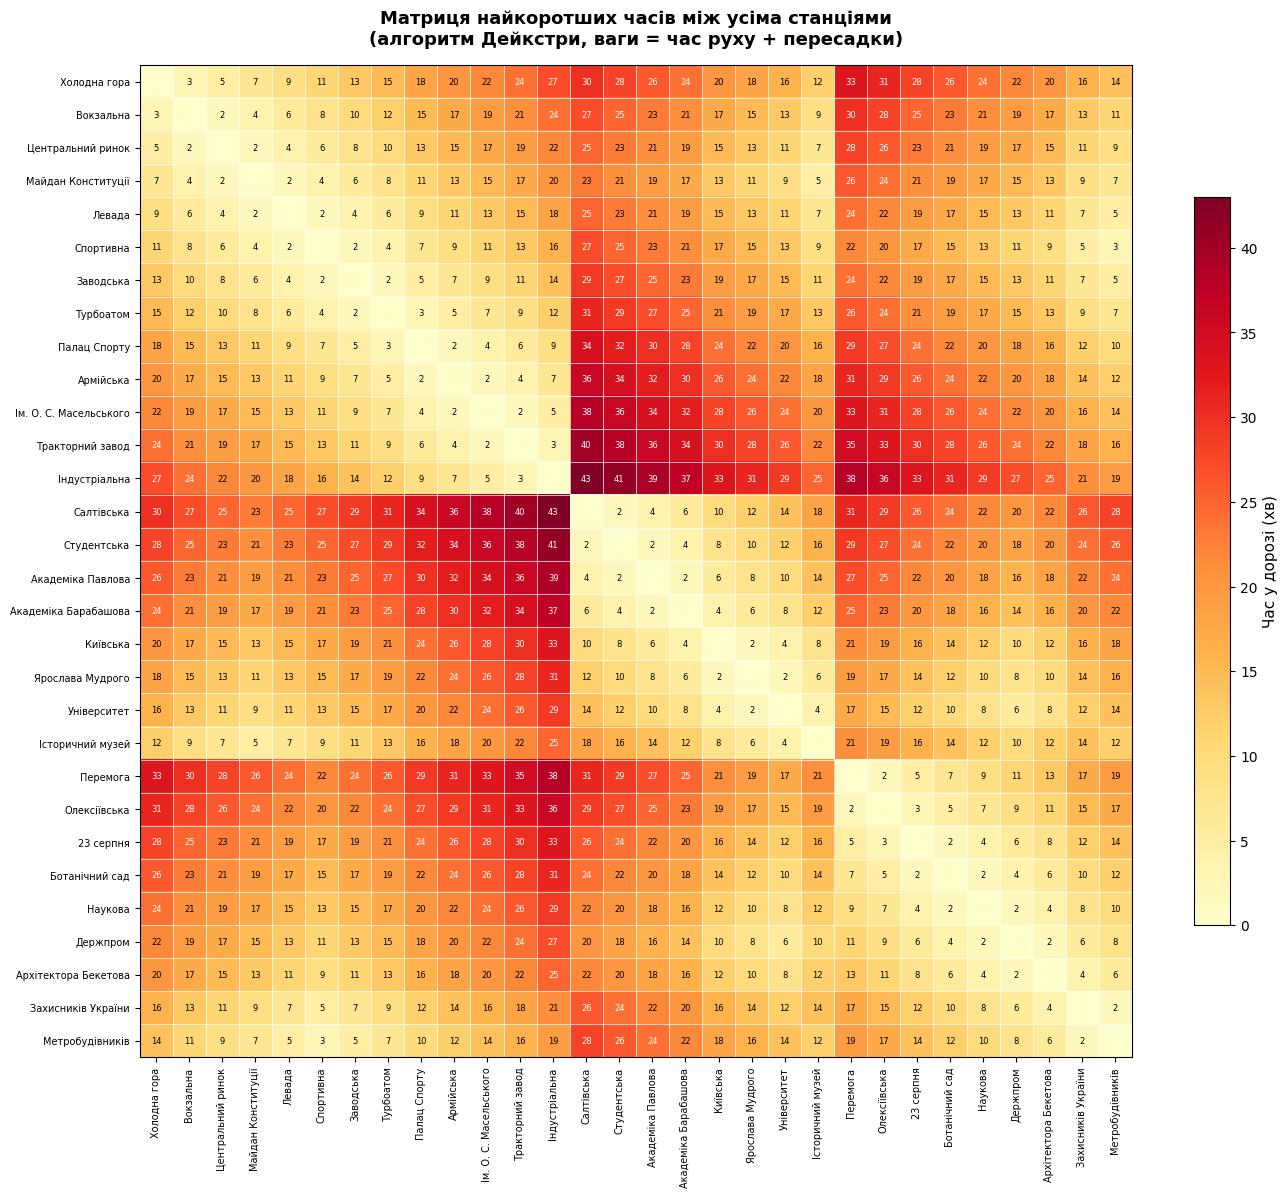

In [19]:
import numpy as np


def draw_time_heatmap(G, lines):
    # Порядок станцій — по лініях, щоб були видно "блоки"
    stations, seen = [], set()
    for line in lines:
        for st in line.stations:
            if st not in seen:
                stations.append(st)
                seen.add(st)

    all_times = all_pairs_shortest_times(G)
    n = len(stations)
    M = np.array([[all_times[s][e] for e in stations] for s in stations])

    fig, ax = plt.subplots(figsize=(14, 12), facecolor='white')
    im = ax.imshow(M, cmap='YlOrRd', aspect='equal')

    ax.set_xticks(range(n));  ax.set_yticks(range(n))
    ax.set_xticklabels(stations, rotation=90, fontsize=7)
    ax.set_yticklabels(stations, fontsize=7)
    ax.set_xticks(np.arange(n + 1) - 0.5, minor=True)
    ax.set_yticks(np.arange(n + 1) - 0.5, minor=True)
    ax.grid(which='minor', color='white', linewidth=0.5)
    ax.tick_params(which='minor', length=0)

    for i in range(n):
        for j in range(n):
            if M[i, j] == 0:
                continue
            color = 'white' if M[i, j] > M.max() * 0.55 else 'black'
            ax.text(j, i, int(M[i, j]), ha='center', va='center',
                    fontsize=6, color=color)

    plt.colorbar(im, ax=ax, shrink=0.7).set_label('Час у дорозі (хв)', fontsize=11)
    ax.set_title("Матриця найкоротших часів між усіма станціями\n"
                 "(алгоритм Дейкстри, ваги = час руху + пересадки)",
                 fontsize=13, fontweight='bold', pad=15)
    plt.tight_layout()
    plt.show()


draw_time_heatmap(GW, LINES)

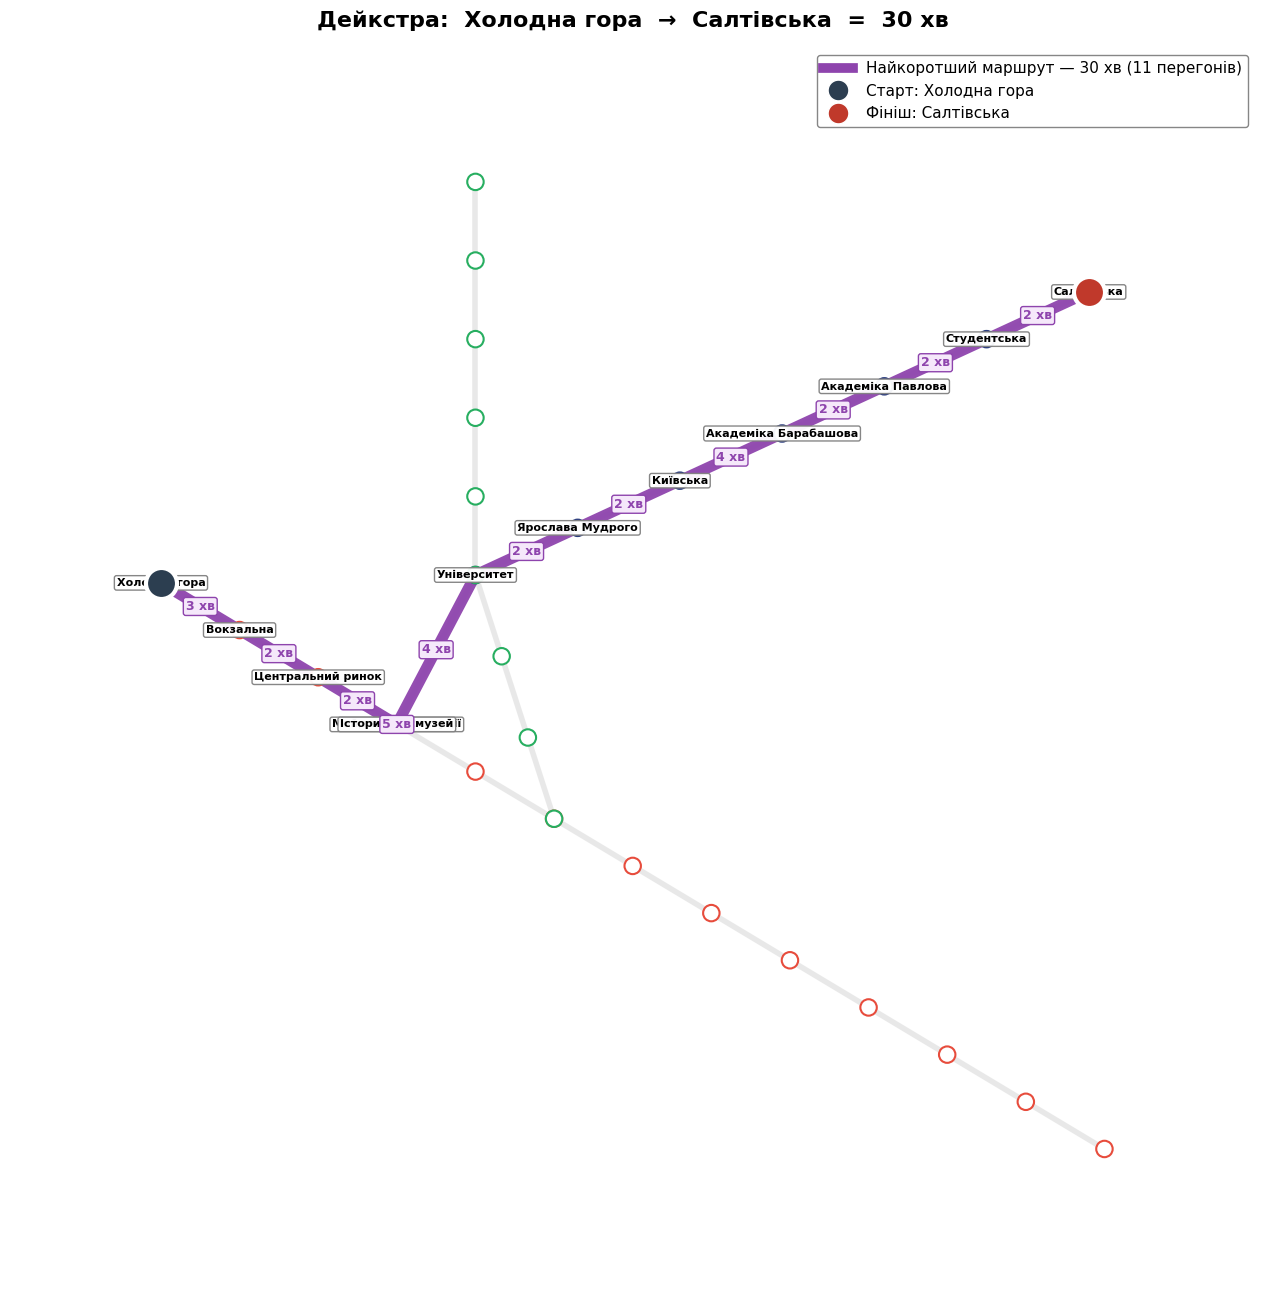

In [20]:
def draw_dijkstra_path(G, lines, transfers, pos, start, end):
    color_of, _, _ = build_indexes(lines, transfers)
    path, total = shortest_path(G, start, end)
    path_edges = list(zip(path, path[1:]))

    fig, ax = plt.subplots(figsize=(18, 13), facecolor='white')

    # Сіра підкладка
    for line in lines:
        edges = list(zip(line.stations, line.stations[1:]))
        nx.draw_networkx_edges(G, pos, edgelist=edges, ax=ax,
                               edge_color='lightgray', width=4, alpha=0.5)
    transfer_edges = [t.stations for t in transfers]
    nx.draw_networkx_edges(G, pos, edgelist=transfer_edges, ax=ax,
                           edge_color='lightgray', width=2, style='dashed', alpha=0.5)
    nx.draw_networkx_nodes(G, pos, ax=ax, node_size=140, node_color='white',
                           edgecolors=[color_of[n] for n in G.nodes()], linewidths=1.5)

    # Маршрут
    nx.draw_networkx_edges(G, pos, edgelist=path_edges, ax=ax,
                           edge_color='#8E44AD', width=8, alpha=0.95)

    # Ваги ребер маршруту — текст у середині кожного ребра
    for u, v in path_edges:
        mx = (pos[u][0] + pos[v][0]) / 2
        my = (pos[u][1] + pos[v][1]) / 2
        ax.text(mx, my, f"{G[u][v]['weight']} хв",
                ha='center', va='center', fontsize=9, fontweight='bold',
                color='#8E44AD', zorder=8,
                bbox=dict(boxstyle='round,pad=0.2', facecolor='#F5E8FA',
                          edgecolor='#8E44AD', linewidth=1))

    # Підписи станцій маршруту
    nx.draw_networkx_labels(G, pos, labels={st: st for st in path}, ax=ax,
                            font_size=8, font_weight='bold',
                            bbox=dict(boxstyle='round,pad=0.2', facecolor='white',
                                      edgecolor='gray', alpha=0.95))
    # Старт / фініш
    for st, col in [(start, '#2C3E50'), (end, '#C0392B')]:
        x, y = pos[st]
        ax.scatter(x, y, s=500, c=col, edgecolors='white', linewidths=3, zorder=10)

    legend_handles = [
        Line2D([0], [0], color='#8E44AD', linewidth=7,
               label=f"Найкоротший маршрут — {total} хв ({len(path)-1} перегонів)"),
        Line2D([0], [0], marker='o', color='w', markerfacecolor='#2C3E50',
               markersize=15, label=f"Старт: {start}"),
        Line2D([0], [0], marker='o', color='w', markerfacecolor='#C0392B',
               markersize=15, label=f"Фініш: {end}"),
    ]
    ax.legend(handles=legend_handles, loc='upper right', fontsize=11,
              framealpha=0.95, edgecolor='gray')
    ax.set_title(f"Дейкстра:  {start}  →  {end}  =  {total} хв",
                 fontsize=16, fontweight='bold', pad=15)
    ax.set_axis_off()
    ax.set_aspect('equal')
    ax.margins(0.1)
    plt.tight_layout()
    plt.show()


draw_dijkstra_path(GW, LINES, TRANSFERS, pos, "Холодна гора", "Салтівська")

## Висновки за результатами алгоритму Дейкстри

### Результати на тестових парах

| Маршрут | Час | Перегонів |
|---|---|---|
| Холодна гора → Салтівська | 30 хв | 11 |
| Університет → Спортивна | 13 хв | 4 |
| Перемога → Індустріальна | 38 хв | 16 |
| Вокзальна → Тракторний завод | 21 хв | 10 |
| Холодна гора → Індустріальна | 27 хв | 12 |

**Зважений діаметр мережі: 43 хв** (Індустріальна → Салтівська). Це найдовший найкоротший шлях у мережі — найгірший сценарій для пасажира, який їде між найвіддаленішими станціями оптимальним маршрутом.

### Чому BFS у завданні 2 і Дейкстра можуть давати різні шляхи

BFS оптимізує **кількість перегонів** і вважає всі ребра однаковими. Дейкстра оптимізує **загальний час** і враховує реальні ваги. У більшості випадків шляхи збігаються — наприклад, Холодна гора → Салтівська (11 перегонів) проходить через ту саму послідовність станцій, бо інші маршрути просто довші у будь-якому сенсі. Але якщо порівняти два альтернативних маршрути через цикл — той, що має менше перегонів, може мати більший час через "дорогі" ребра (довгі пересадки 5-6 хв або довші перегони 4 хв між Київською та Академікою Барабашовою). Дейкстра може обрати інший маршрут, ніж BFS.

### Аналіз теплової карти

На матриці найкоротших часів чітко видно **блокову структуру**: світлі трикутники по діагоналі — це поїздки в межах однієї лінії (швидкі), а яскраво-червоні зони — поїздки між кінцевими станціями різних ліній з обов'язковими пересадками. Пересадки додають 3–6 хв "штрафу" до часу маршруту, що добре пояснює, чому деякі переміщення дорого коштують навіть на відносно невелику кількість перегонів.

### Що матриця всіх найкоротших шляхів дає для аналізу мережі

Маючи матрицю V×V = 30×30 = 900 значень найкоротших часів, можна обчислити агреговані характеристики: середній час поїздки в мережі, ідентифікувати "найдешевші" та "найдорожчі" пари станцій, оцінити вплив додавання або видалення ребра/пересадки на загальну зв'язність. Це класичний інструмент для планування транспорту: на основі цієї матриці визначають, наприклад, де варто будувати нову пересадку, щоб максимально зменшити середній час поїздки в мережі.

## Порівняння BFS і Дейкстри на тих самих парах станцій

BFS оптимізує **кількість перегонів**, Дейкстра — **загальний час**. У більшості випадків ці критерії дають той самий маршрут, але є пари, де вони розходяться: коли коротший за перегонами шлях має "дорогі" ребра (довгі пересадки 5-6 хв або 4-хвилинні перегони між «Київська ↔ Академіка Барабашова» та «Архітектора Бекетова ↔ Захисників України»). У нашому графі таких пар знайдеться **11 з 435 можливих** — приблизно 2.5%. Знайдемо їх програмно і покажемо найкращий приклад.

In [21]:
def path_time(G, path):
    return sum(G[path[i]][path[i+1]]['weight'] for i in range(len(path) - 1))


# Шукаємо пари, де BFS і Дейкстра дають різні маршрути за вершинами
diff_pairs = []
nodes = list(GW.nodes())
for i, s in enumerate(nodes):
    for e in nodes[i+1:]:
        bfs = bfs_path(GW, s, e)
        dijk, _ = shortest_path(GW, s, e)
        if bfs != dijk and bfs[::-1] != dijk:
            diff_pairs.append((s, e, len(bfs)-1, path_time(GW, bfs),
                                     len(dijk)-1, path_time(GW, dijk)))

print(f"Пар з різними маршрутами: {len(diff_pairs)} з "
      f"{len(nodes)*(len(nodes)-1)//2} можливих\n")

print(f"{'Пара':<55} {'BFS':>14}  {'Дейкстра':>14}  {'Економія':>9}")
print("=" * 100)
for s, e, n_b, t_b, n_d, t_d in diff_pairs:
    pair = f"{s} → {e}"
    print(f"{pair:<55} {n_b} рб, {t_b:>2} хв     {n_d} рб, {t_d:>2} хв   {t_b - t_d:>4} хв")

Пар з різними маршрутами: 11 з 435 можливих

Пара                                                               BFS        Дейкстра   Економія
Холодна гора → Архітектора Бекетова                     7 рб, 24 хв     8 рб, 20 хв      4 хв
Вокзальна → Архітектора Бекетова                        6 рб, 21 хв     7 рб, 17 хв      4 хв
Центральний ринок → Архітектора Бекетова                5 рб, 19 хв     6 рб, 15 хв      4 хв
Майдан Конституції → Архітектора Бекетова               4 рб, 17 хв     5 рб, 13 хв      4 хв
Левада → Перемога                                       9 рб, 28 хв     10 рб, 24 хв      4 хв
Левада → Олексіївська                                   8 рб, 26 хв     9 рб, 22 хв      4 хв
Левада → 23 серпня                                      7 рб, 23 хв     8 рб, 19 хв      4 хв
Левада → Ботанічний сад                                 6 рб, 21 хв     7 рб, 17 хв      4 хв
Левада → Наукова                                        5 рб, 19 хв     6 рб, 15 хв      4 хв
Левада → Д

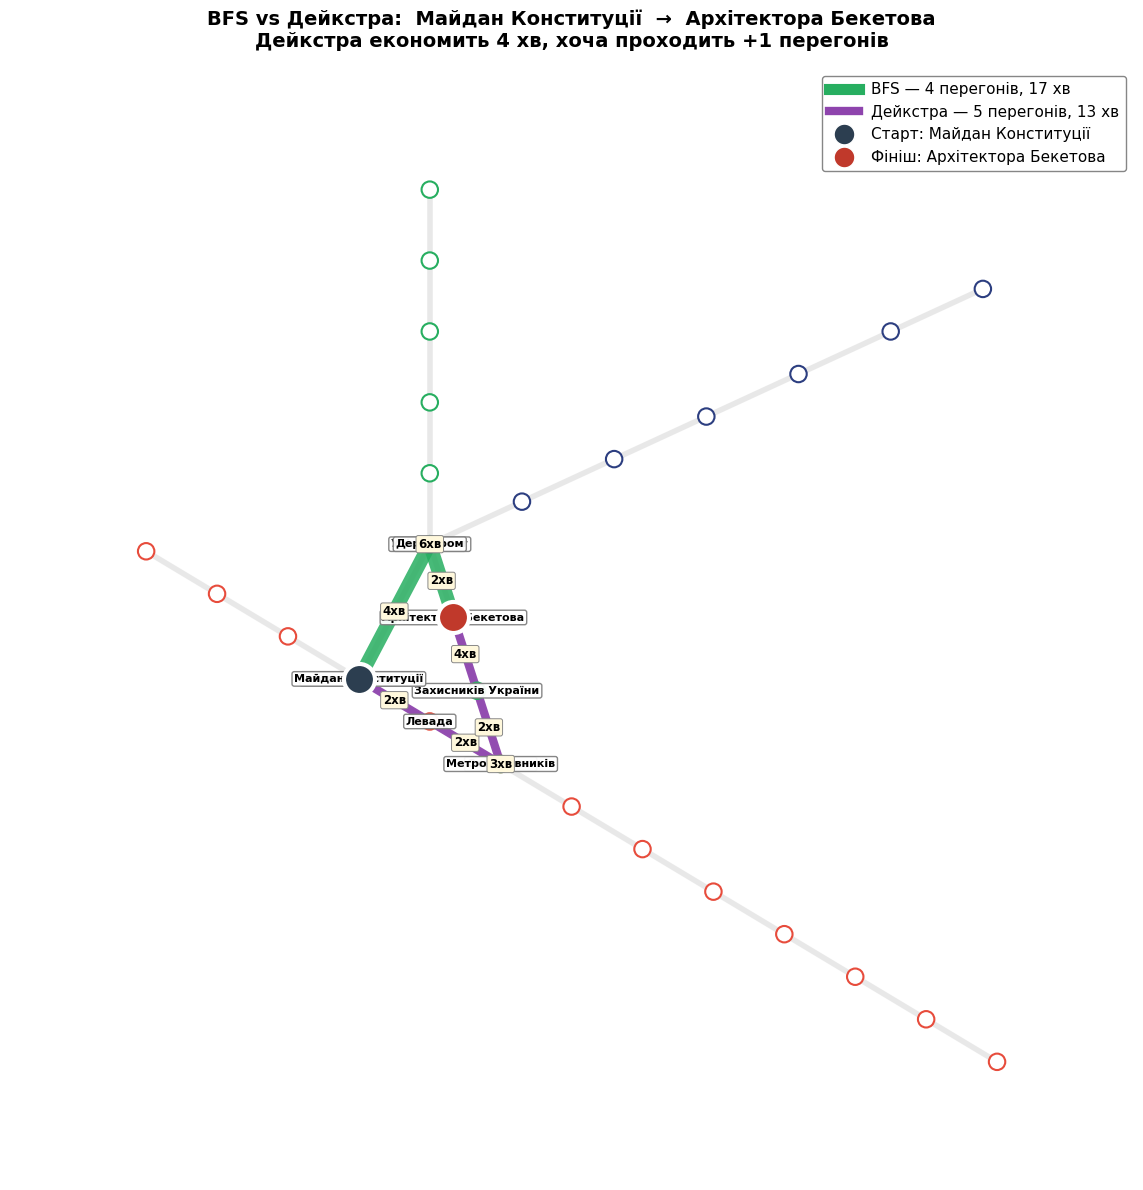

In [22]:
def draw_bfs_vs_dijkstra(G, lines, transfers, pos, start, end):
    color_of, _, _ = build_indexes(lines, transfers)
    bfs    = bfs_path(G, start, end)
    dijk,_ = shortest_path(G, start, end)
    bfs_t  = path_time(G, bfs)
    dijk_t = path_time(G, dijk)
    bfs_e  = list(zip(bfs, bfs[1:]))
    dijk_e = list(zip(dijk, dijk[1:]))

    fig, ax = plt.subplots(figsize=(16, 12), facecolor='white')

    # Сіра підкладка
    for line in lines:
        edges = list(zip(line.stations, line.stations[1:]))
        nx.draw_networkx_edges(G, pos, edgelist=edges, ax=ax,
                               edge_color='lightgray', width=4, alpha=0.5)
    transfer_edges = [t.stations for t in transfers]
    nx.draw_networkx_edges(G, pos, edgelist=transfer_edges, ax=ax,
                           edge_color='lightgray', width=2, style='dashed', alpha=0.5)
    nx.draw_networkx_nodes(G, pos, ax=ax, node_size=140, node_color='white',
                           edgecolors=[color_of[n] for n in G.nodes()], linewidths=1.5)

    # BFS під сподом, Дейкстра поверх
    nx.draw_networkx_edges(G, pos, edgelist=bfs_e, ax=ax,
                           edge_color='#27AE60', width=10, alpha=0.85)
    nx.draw_networkx_edges(G, pos, edgelist=dijk_e, ax=ax,
                           edge_color='#8E44AD', width=6, alpha=0.95)

    # Ваги ребер обох маршрутів (об'єднання)
    drawn = set()
    for u, v in bfs_e + dijk_e:
        key = frozenset([u, v])
        if key in drawn:
            continue
        drawn.add(key)
        mx = (pos[u][0] + pos[v][0]) / 2
        my = (pos[u][1] + pos[v][1]) / 2
        ax.text(mx, my, f"{G[u][v]['weight']}хв",
                ha='center', va='center', fontsize=8.5, fontweight='bold',
                color='black', zorder=8,
                bbox=dict(boxstyle='round,pad=0.18', facecolor='#FFF8DC',
                          edgecolor='#888', linewidth=0.7))

    # Старт / фініш
    for st, col in [(start, '#2C3E50'), (end, '#C0392B')]:
        x, y = pos[st]
        ax.scatter(x, y, s=500, c=col, edgecolors='white',
                   linewidths=3, zorder=10)

    # Підписи задіяних станцій
    used = set(bfs) | set(dijk)
    nx.draw_networkx_labels(G, pos, labels={st: st for st in used}, ax=ax,
                            font_size=8, font_weight='bold',
                            bbox=dict(boxstyle='round,pad=0.2', facecolor='white',
                                      edgecolor='gray', alpha=0.95))

    legend_handles = [
        Line2D([0], [0], color='#27AE60', linewidth=8,
               label=f'BFS — {len(bfs)-1} перегонів, {bfs_t} хв'),
        Line2D([0], [0], color='#8E44AD', linewidth=6,
               label=f'Дейкстра — {len(dijk)-1} перегонів, {dijk_t} хв'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor='#2C3E50',
               markersize=15, label=f'Старт: {start}'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor='#C0392B',
               markersize=15, label=f'Фініш: {end}'),
    ]
    ax.legend(handles=legend_handles, loc='upper right', fontsize=11,
              framealpha=0.95, edgecolor='gray')

    saved = bfs_t - dijk_t
    ax.set_title(f"BFS vs Дейкстра:  {start}  →  {end}\n"
                 f"Дейкстра економить {saved} хв, хоча проходить "
                 f"{len(dijk) - len(bfs):+d} перегонів",
                 fontsize=14, fontweight='bold', pad=15)
    ax.set_axis_off()
    ax.set_aspect('equal')
    ax.margins(0.1)
    plt.tight_layout()
    plt.show()


draw_bfs_vs_dijkstra(GW, LINES, TRANSFERS, pos,
                     "Майдан Конституції", "Архітектора Бекетова")

### Аналіз прикладу: Майдан Конституції → Архітектора Бекетова

Дві станції лежать на центральному циклі мережі та можуть бути з'єднані двома альтернативними маршрутами навколо цього циклу — за годинниковою стрілкою або проти.

**Шлях BFS** (4 перегони, 17 хв) — мінімізує кількість зупинок. Іде «коротшою стороною» через дві пересадки: Майдан Конституції → Історичний музей (5 хв) → Університет (4 хв) → Держпром (6 хв) → Архітектора Бекетова (2 хв). Сума двох пересадок дає 11 хв "штрафу" — алгоритм цього не бачить, бо рахує лише ребра.

**Шлях Дейкстри** (5 перегонів, 13 хв) — мінімізує час у дорозі. Іде «довшою стороною» через одну дешеву пересадку: Майдан Конституції → Левада (2 хв) → Спортивна (2 хв) → Метробудівників (3 хв) → Захисників України (2 хв) → Архітектора Бекетова (4 хв). Один зайвий перегон, але дешева пересадка Спортивна/Метробудівників (3 хв) суттєво виграє у дорогих Іст.музей/Майдан + Університет/Держпром (5 + 6 = 11 хв).

**Економія Дейкстри становить 4 хвилини** — це 23% від часу BFS. Цей приклад чітко демонструє, що при оптимізації маршрутів у реальній транспортній мережі важлива не кількість зупинок, а реальний час руху, який враховує час перегонів і час пересадок між лініями.

### Загальний висновок

Із 435 можливих пар станцій ($C^2_{30} = 435$) лише в 11 (близько 2.5%) BFS і Дейкстра дають різні маршрути. У всіх цих 11 випадках Дейкстра проходить через **на один перегон більше**, але через **меншу кількість дорогих пересадок** — і виграє в часі від 2 до 4 хв. Це типовий патерн для транспортних мереж: оптимізація за реальним часом часто потребує «жертви» додатковими перегонами заради уникнення довгих пересадок.

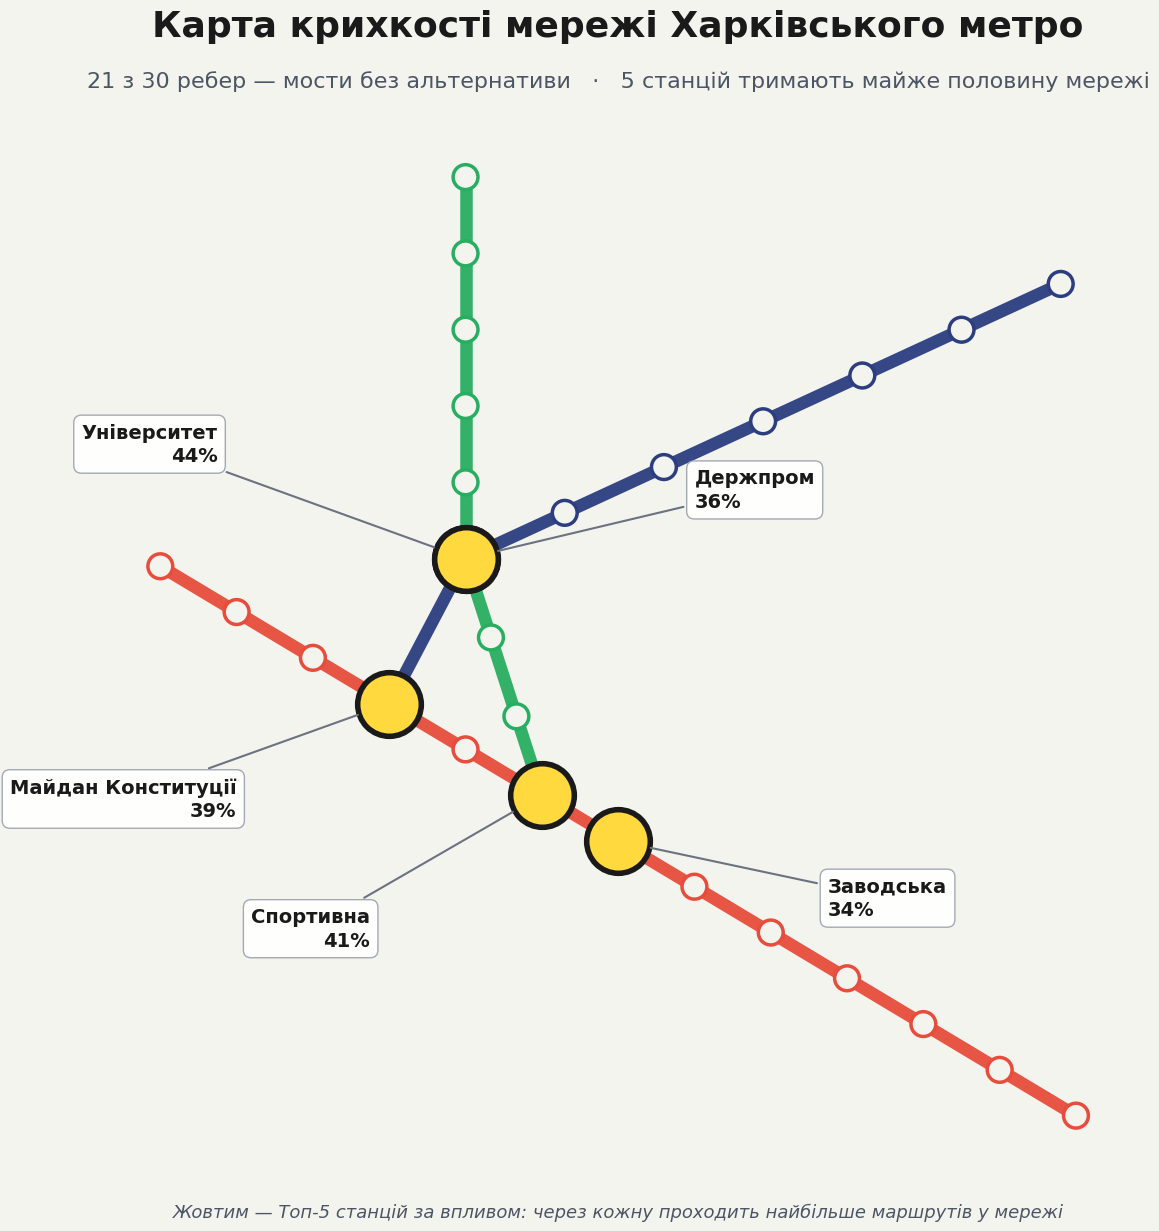

In [23]:
def draw_fragility_map(G, lines, transfers, pos, top_n=5, save_path=None):
    color_of, _, _ = build_indexes(lines, transfers)

    bc = nx.betweenness_centrality(G)
    top_stations = sorted(bc.items(), key=lambda kv: kv[1], reverse=True)[:top_n]
    top_set = {st for st, _ in top_stations}

    def edge_color(edge):
        u, v = edge
        for line in lines:
            if u in line.stations and v in line.stations:
                return line.color
        return '#2C3E50'  # пересадки

    from collections import defaultdict
    by_color = defaultdict(list)
    for e in G.edges():
        by_color[edge_color(e)].append(e)

    BG, TEXT, SUB = '#F4F4EF', '#1A1A1A', '#4B5563'
    TOP_FILL, TOP_EDGE = '#FFD93D', '#1A1A1A'
    BOX_EDGE = '#9CA3AF'
    CALLOUT_CLR = '#6B7280'

    label_offsets = {
        'Університет':        (-6.5,  3.0, 'right',  'center'),
        'Держпром':           ( 6.0,  1.8, 'left',   'center'),
        'Майдан Конституції': (-4.0, -2.5, 'right',  'center'),
        'Спортивна':          (-4.5, -3.5, 'right',  'center'),
        'Заводська':          ( 5.5, -1.5, 'left',   'center'),
    }

    fig, ax = plt.subplots(figsize=(16, 13), facecolor=BG)
    ax.set_facecolor(BG)
    ax.set_axis_off()
    ax.set_aspect('equal')

    all_xs = [pos[n][0] for n in G.nodes()] + \
             [pos[st][0] + dx for st, (dx, _, _, _) in label_offsets.items()]
    all_ys = [pos[n][1] for n in G.nodes()] + \
             [pos[st][1] + dy for st, (_, dy, _, _) in label_offsets.items()]
    pad = 1.5
    ax.set_xlim(min(all_xs) - pad, max(all_xs) + pad)
    ax.set_ylim(min(all_ys) - pad, max(all_ys) + pad)

    # Усі ребра — суцільні, у натуральних кольорах ліній
    for clr, edges in by_color.items():
        nx.draw_networkx_edges(G, pos, edgelist=edges, ax=ax,
                               edge_color=clr, width=9, alpha=0.95)

    # Звичайні вузли
    regular = [n for n in G.nodes() if n not in top_set]
    nx.draw_networkx_nodes(G, pos, nodelist=regular, ax=ax,
                           node_size=320, node_color=BG,
                           edgecolors=[color_of[n] for n in regular],
                           linewidths=2.5)

    # Топ-5 — фокусні золоті
    top_nodes = [st for st, _ in top_stations]
    nx.draw_networkx_nodes(G, pos, nodelist=top_nodes, ax=ax,
                           node_size=2100, node_color=TOP_FILL,
                           edgecolors=TOP_EDGE, linewidths=4)

    # Callout-лейбли
    for st, bc_val in top_stations:
        x, y = pos[st]
        dx, dy, ha, va = label_offsets[st]
        ax.annotate(
            f"{st}\n{bc_val*100:.0f}%",
            xy=(x, y),
            xytext=(x + dx, y + dy),
            fontsize=14, fontweight='bold',
            color=TEXT, ha=ha, va=va, linespacing=1.3,
            bbox=dict(boxstyle='round,pad=0.4', facecolor='white',
                      edgecolor=BOX_EDGE, alpha=0.92, linewidth=1),
            arrowprops=dict(arrowstyle='-', color=CALLOUT_CLR,
                            linewidth=1.5, shrinkA=2, shrinkB=24),
            zorder=10,
        )

    # Мінімальний caption замість легенди
    fig.text(0.5, 0.05,
             "Жовтим — Топ-5 станцій за впливом: через кожну проходить найбільше маршрутів у мережі",
             ha='center', va='center', fontsize=13, color=SUB, fontstyle='italic')

    # Title
    fig.text(0.5, 0.975, "Карта крихкості мережі Харківського метро",
             ha='center', va='top', fontsize=26, fontweight='bold', color=TEXT)
    fig.text(0.5, 0.928,
             "21 з 30 ребер — мости без альтернативи   ·   "
             "5 станцій тримають майже половину мережі",
             ha='center', va='top', fontsize=16, color=SUB)

    plt.subplots_adjust(top=0.89, bottom=0.08, left=0.02, right=0.98)

    if save_path:
        fig.savefig(save_path, dpi=200, bbox_inches='tight', facecolor=BG)
    plt.show()


draw_fragility_map(G, LINES, TRANSFERS, pos, save_path='fragility_map.png')

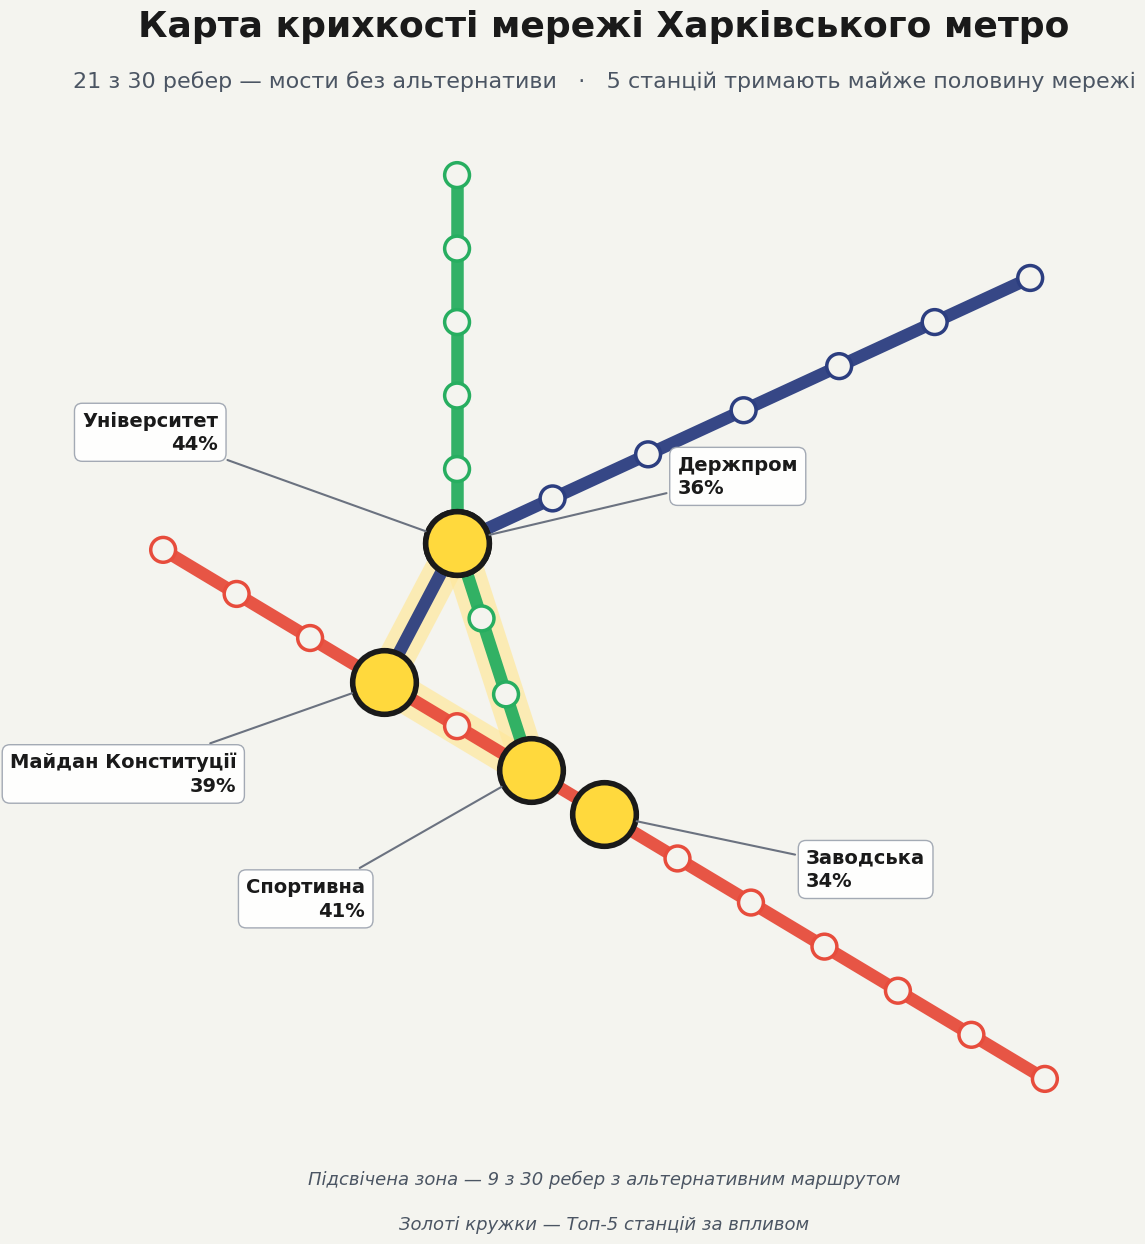

In [24]:
def draw_fragility_map(G, lines, transfers, pos, top_n=5, save_path=None):
    color_of, _, _ = build_indexes(lines, transfers)

    # 9 ребер циклу (з альтернативою) — те, що буде підсвічено
    bridges = set(map(frozenset, nx.bridges(G)))
    cycle_edges = [e for e in G.edges() if frozenset(e) not in bridges]

    bc = nx.betweenness_centrality(G)
    top_stations = sorted(bc.items(), key=lambda kv: kv[1], reverse=True)[:top_n]
    top_set = {st for st, _ in top_stations}

    def edge_color(edge):
        u, v = edge
        for line in lines:
            if u in line.stations and v in line.stations:
                return line.color
        return '#2C3E50'

    from collections import defaultdict
    by_color = defaultdict(list)
    for e in G.edges():
        by_color[edge_color(e)].append(e)

    BG, TEXT, SUB = '#F4F4EF', '#1A1A1A', '#4B5563'
    TOP_FILL, TOP_EDGE = '#FFD93D', '#1A1A1A'
    BOX_EDGE = '#9CA3AF'
    CALLOUT_CLR = '#6B7280'
    HALO_CLR = '#FFE89C'  # світло-жовтий — підсвічена зона альтернатив

    label_offsets = {
        'Університет':        (-6.5,  3.0, 'right',  'center'),
        'Держпром':           ( 6.0,  1.8, 'left',   'center'),
        'Майдан Конституції': (-4.0, -2.5, 'right',  'center'),
        'Спортивна':          (-4.5, -3.5, 'right',  'center'),
        'Заводська':          ( 5.5, -1.5, 'left',   'center'),
    }

    fig, ax = plt.subplots(figsize=(16, 13), facecolor=BG)
    ax.set_facecolor(BG)
    ax.set_axis_off()
    ax.set_aspect('equal')

    all_xs = [pos[n][0] for n in G.nodes()] + \
             [pos[st][0] + dx for st, (dx, _, _, _) in label_offsets.items()]
    all_ys = [pos[n][1] for n in G.nodes()] + \
             [pos[st][1] + dy for st, (_, dy, _, _) in label_offsets.items()]
    pad = 1.5
    ax.set_xlim(min(all_xs) - pad, max(all_xs) + pad)
    ax.set_ylim(min(all_ys) - pad, max(all_ys) + pad)

    # 1. HALO — найперший шар, лежить під усім
    nx.draw_networkx_edges(G, pos, edgelist=cycle_edges, ax=ax,
                           edge_color=HALO_CLR, width=26, alpha=0.7)

    # 2. Усі ребра — суцільні в натуральних кольорах, поверх halo
    for clr, edges in by_color.items():
        nx.draw_networkx_edges(G, pos, edgelist=edges, ax=ax,
                               edge_color=clr, width=9, alpha=0.95)

    # 3. Звичайні вузли
    regular = [n for n in G.nodes() if n not in top_set]
    nx.draw_networkx_nodes(G, pos, nodelist=regular, ax=ax,
                           node_size=320, node_color=BG,
                           edgecolors=[color_of[n] for n in regular],
                           linewidths=2.5)

    # 4. Топ-5 — золоті
    top_nodes = [st for st, _ in top_stations]
    nx.draw_networkx_nodes(G, pos, nodelist=top_nodes, ax=ax,
                           node_size=2100, node_color=TOP_FILL,
                           edgecolors=TOP_EDGE, linewidths=4)

    # 5. Callout-лейбли
    for st, bc_val in top_stations:
        x, y = pos[st]
        dx, dy, ha, va = label_offsets[st]
        ax.annotate(
            f"{st}\n{bc_val*100:.0f}%",
            xy=(x, y),
            xytext=(x + dx, y + dy),
            fontsize=14, fontweight='bold',
            color=TEXT, ha=ha, va=va, linespacing=1.3,
            bbox=dict(boxstyle='round,pad=0.4', facecolor='white',
                      edgecolor=BOX_EDGE, alpha=0.92, linewidth=1),
            arrowprops=dict(arrowstyle='-', color=CALLOUT_CLR,
                            linewidth=1.5, shrinkA=2, shrinkB=24),
            zorder=10,
        )

    # Caption — два короткі рядки внизу
    fig.text(0.5, 0.075,
             "Підсвічена зона — 9 з 30 ребер з альтернативним маршрутом",
             ha='center', va='center', fontsize=13, color=SUB, fontstyle='italic')
    fig.text(0.5, 0.040,
             "Золоті кружки — Топ-5 станцій за впливом",
             ha='center', va='center', fontsize=13, color=SUB, fontstyle='italic')

    # Title
    fig.text(0.5, 0.975, "Карта крихкості мережі Харківського метро",
             ha='center', va='top', fontsize=26, fontweight='bold', color=TEXT)
    fig.text(0.5, 0.928,
             "21 з 30 ребер — мости без альтернативи   ·   "
             "5 станцій тримають майже половину мережі",
             ha='center', va='top', fontsize=16, color=SUB)

    plt.subplots_adjust(top=0.89, bottom=0.11, left=0.02, right=0.98)

    if save_path:
        fig.savefig(save_path, dpi=200, bbox_inches='tight', facecolor=BG)
    plt.show()


draw_fragility_map(G, LINES, TRANSFERS, pos, save_path='fragility_map.png')